In [1]:
# Cell 1A: imports and paths

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt

PROJ_ROOT = Path("~").expanduser() / "Desktop" / "shockley_repo"
DATA = PROJ_ROOT / "data"
FIGURES = PROJ_ROOT / "figures" / "figures_Hurdle" / "figures_Hurdle_AR1_GRW_PG_ZD"
RESULTS = PROJ_ROOT / "results" / "results_Hurdle" / "results_Hurdle_AR1_GRW_PG_ZD"

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "Hurdle-AR(1)-GRW-PG-ZD"
MODEL_TAG = "hurdle_ar1_grw_pg_zd"


In [2]:
# Cell 1B: analysis settings

EPS = 0.49
N = 50000
Y = 20
SEED = 63

MIN_PROB = 1e-6
MAX_PROB = 1 - 1e-6
MIN_POS_Q = 1e-12

rng = np.random.default_rng(SEED)

stage_spans = [
    (0, 4,  "0.70", "0-4"),
    (5, 7,  "0.78", "5-7"),
    (8, 13, "0.86", "8-13"),
    (14, 20,"0.93", "14-20")]


In [3]:
# Cell 1C: load data

df_original = pd.read_csv(DATA / "adjusted_productivity.csv")

print(df_original.shape)
df_original.head()


(54948, 21)


,contribs,contribs_with_corr,current,dblp,department,facultyName,first_asst_job_rank,first_asst_job_year,has_postdoc,is_female,...,phd_rank,phd_year,place,pubs,pubs_adj,pubs_with_corr,pubs_with_corr_adj,recordDate,year,CareerAge
0,0.342857,0.342857,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,2,3.902057,2,3.902057,6/6/11,1998,-3
1,0.250000,0.250000,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,1,1.875160,1,1.875160,6/6/11,1999,-2
2,1.833333,1.833333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,7.214900,4,7.214900,6/6/11,2000,-1
3,1.583333,1.583333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,3,5.209137,3,5.209137,6/6/11,2001,0
4,1.444444,1.444444,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,6.691238,4,6.691238,6/6/11,2002,1


In [4]:
# Cell 4: build empirical panel

df_original['dblp_id'] = df_original['dblp'] + df_original['phd_year'].astype(str)
working_df = (df_original.sort_values(["dblp_id", "CareerAge"]).copy())

working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"] + EPS)
working_df["is_active"] = (working_df["pubs_adj"] > 0).astype(int)

working_df["pubs_adj_next"] = working_df.groupby("dblp_id")["pubs_adj"].shift(-1)
working_df["CareerAge_next"] = working_df.groupby("dblp_id")["CareerAge"].shift(-1)
working_df["log_pubs_next"] = working_df.groupby("dblp_id")["log_pubs_adj"].shift(-1)
working_df["is_active_next"] = working_df.groupby("dblp_id")["is_active"].shift(-1)

working_df["log_delta"] = working_df["log_pubs_next"] - working_df["log_pubs_adj"]

is_next_year = working_df["CareerAge_next"].eq(working_df["CareerAge"] + 1)
is_in_window = working_df["CareerAge"].between(0, Y - 1)

working_df_fit = (working_df[is_next_year & is_in_window].dropna(subset=["pubs_adj", "pubs_adj_next", "is_active", "is_active_next"]).copy())

print("Rows in orig:", len(working_df))
print("Rows w/ ok 1yr trans:", len(working_df_fit))
print()
print(working_df_fit[["pubs_adj", "pubs_adj_next", "log_pubs_adj", "log_pubs_next", "log_delta"]].describe())


Rows in orig: 54948
Rows w/ ok 1yr trans: 34701

           pubs_adj  pubs_adj_next  log_pubs_adj  log_pubs_next     log_delta
count  34701.000000   34701.000000  34701.000000   34701.000000  34701.000000
mean       6.426378       6.446431      1.442084       1.448262      0.006178
std        6.475154       6.499782      1.131298       1.123265      1.057639
min        0.000000       0.000000     -0.713350      -0.713350     -5.028100
25%        2.031715       2.031715      0.924939       0.924939     -0.509761
50%        4.775004       4.775004      1.661082       1.661082     -0.026502
75%        9.012406       9.012406      2.251545       2.251545      0.523108
max       80.686837      80.686837      4.396630       4.396630      4.138016


In [5]:
# Cell 3: career stages

stage_order = ["0-4", "5-7", "8-13", "14-20"]

def assign_career_stage(year):
    if 0 <= year <= 4:
        return "0-4"
    elif 5 <= year <= 7:
        return "5-7"
    elif 8 <= year <= 13:
        return "8-13"
    elif 14 <= year <= 20:
        return "14-20"
    else:
        return np.nan

working_df["career_stage"] = working_df["CareerAge"].apply(assign_career_stage)
working_df_fit["career_stage"] = working_df_fit["CareerAge"].apply(assign_career_stage)

print("Prod obs by stage:")
print(working_df["career_stage"].value_counts().reindex(stage_order))
print()
print("Trans obs by starting-year stage:")
print(working_df_fit["career_stage"].value_counts().reindex(stage_order))


Prod obs by stage:
career_stage
0-4      10961
5-7       6647
8-13     11114
14-20     8404
Name: count, dtype: int64

Trans obs by starting-year stage:
career_stage
0-4      10918
5-7       6401
8-13     10496
14-20     6886
Name: count, dtype: int64


In [6]:
# Cell 4: build binary states and transition data

id_col = "dblp_id"
age_col = "CareerAge"
prod_col = "pubs_adj"

state_labels = {
    0: "No pubs",
    1: "Some pubs",}

state_order = [0, 1]
n_states = len(state_order)

df = working_df[working_df[age_col].between(0, Y)].copy()
df = df.sort_values([id_col, age_col]).copy()
df["state"] = (df[prod_col] > 0).astype(int)


def compute_zero_run_length(state_series):
    arr = state_series.to_numpy(dtype=int)
    out = np.zeros(len(arr), dtype=int)
    run = 0
    for i, s in enumerate(arr):
        if s == 0:
            run += 1
            out[i] = run
        else:
            run = 0
            out[i] = 0
    return pd.Series(out, index=state_series.index)


df["zero_run_length"] = (
    df.groupby(id_col, sort=False)["state"]
      .transform(compute_zero_run_length)
      .astype(int)
)

trans = working_df_fit.copy()
trans["state"] = trans["is_active"].astype(int)
trans["next_state"] = trans["is_active_next"].astype(int)
trans = trans.merge(
    df[[id_col, age_col, "zero_run_length"]],
    on=[id_col, age_col],
    how="left"
)
trans["zero_run_length"] = trans["zero_run_length"].fillna(0).astype(int)

print(df[[id_col, age_col, prod_col, "state", "zero_run_length"]].head())
print()
print("State counts:")
print(df["state"].map(state_labels).value_counts())
print()
print("Transition counts by type:")
print(pd.crosstab(trans["state"], trans["next_state"]).rename(index=state_labels, columns=state_labels))
print()
print("Zero-run length summary among zero states:")
print(df.loc[df["state"] == 0, "zero_run_length"].describe())


                        dblp_id  CareerAge   pubs_adj  state  zero_run_length
3  =Ccedil=etintemel:Ugur2001.0          0   5.209137      1                0
4  =Ccedil=etintemel:Ugur2001.0          1   6.691238      1                0
5  =Ccedil=etintemel:Ugur2001.0          2  12.901876      1                0
6  =Ccedil=etintemel:Ugur2001.0          3   4.667694      1                0
7  =Ccedil=etintemel:Ugur2001.0          4  12.016541      1                0

State counts:
state
Some pubs    31549
No pubs       5577
Name: count, dtype: int64

Transition counts by type:
next_state  No pubs  Some pubs
state                         
No pubs        2318       3061
Some pubs      2823      26499

Zero-run length summary among zero states:
count    5577.00000
mean        2.10615
std         2.02394
min         1.00000
25%         1.00000
50%         1.00000
75%         2.00000
max        18.00000
Name: zero_run_length, dtype: float64


In [7]:
# Cell 5A: yearwise binary transition matrices

def transition_counts_and_probs(g):
    counts = pd.crosstab(g["state"], g["next_state"])
    counts = counts.reindex(index=state_order, columns=state_order, fill_value=0)
    probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    return counts, probs

global_counts, global_P = transition_counts_and_probs(trans)

year_counts = {}
year_P = {}

year_transition_rows = []

for year in range(Y):
    g = trans[trans[age_col] == year]
    counts, probs = transition_counts_and_probs(g)

    probs = probs.combine_first(global_P)

    year_counts[year] = counts
    year_P[year] = probs

    year_transition_rows.append({
        "year": year,
        "n": int(counts.values.sum()),
        "P_nothing_to_nothing": probs.loc[0, 0],
        "P_nothing_to_something": probs.loc[0, 1],
        "P_something_to_nothing": probs.loc[1, 0],
        "P_something_to_something": probs.loc[1, 1],})

year_transition_summary = pd.DataFrame(year_transition_rows)

print("Global transition probabilities:")
print(global_P.rename(index=state_labels, columns=state_labels).round(3))
print()
print("Yearwise transition summary:")
display(year_transition_summary.round(3))


Global transition probabilities:
next_state  No pubs  Some pubs
state                         
No pubs       0.431      0.569
Some pubs     0.096      0.904

Yearwise transition summary:


,year,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0,2067,0.380,0.620,0.164,0.836
1,1,2143,0.316,0.684,0.109,0.891
2,2,2202,0.362,0.638,0.075,0.925
3,3,2247,0.380,0.620,0.082,0.918
4,4,2259,0.408,0.592,0.076,0.924
5,5,2200,0.442,0.558,0.077,0.923
6,6,2142,0.408,0.592,0.078,0.922
7,7,2059,0.407,0.593,0.095,0.905
8,8,1985,0.407,0.593,0.086,0.914
9,9,1895,0.483,0.517,0.094,0.906


In [8]:
# Cell 5B: stagewise binary transition summary

stage_counts = {}
stage_P = {}
stage_transition_rows = []

for stage in stage_order:
    g = trans[trans["career_stage"] == stage]
    counts, probs = transition_counts_and_probs(g)
    probs = probs.combine_first(global_P)

    stage_counts[stage] = counts
    stage_P[stage] = probs

    stage_transition_rows.append({
        "stage": stage,
        "n": int(counts.values.sum()),
        "P_nothing_to_nothing": probs.loc[0, 0],
        "P_nothing_to_something": probs.loc[0, 1],
        "P_something_to_nothing": probs.loc[1, 0],
        "P_something_to_something": probs.loc[1, 1],})

stage_transition_summary = pd.DataFrame(stage_transition_rows)

display(stage_transition_summary.round(3))


,stage,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0-4,10918,0.365,0.635,0.099,0.901
1,5-7,6401,0.419,0.581,0.083,0.917
2,8-13,10496,0.463,0.537,0.094,0.906
3,14-20,6886,0.485,0.515,0.109,0.891


logistic dropout model
Converged: True
Negative log-likelihood: 8604.202
Fitted gamma on log(1 + Q_t): 1.1886



,year,n_active_transitions,observed_dropout_rate,dropout_intercept,dropout_gamma_log1p_q,pred_drop_q25,pred_drop_q50,pred_drop_q75,pred_drop_q95
0,0,1633,0.1641,0.2482,1.1886,0.1876,0.1156,0.0688,0.0338
1,1,1710,0.1088,-0.2217,1.1886,0.1261,0.0755,0.0441,0.0214
2,2,1879,0.0750,-0.4681,1.1886,0.1014,0.0600,0.0348,0.0168
3,3,1989,0.0825,-0.2655,1.1886,0.1214,0.0725,0.0423,0.0205
4,4,1997,0.0756,-0.2912,1.1886,0.1187,0.0708,0.0413,0.0200
5,5,1942,0.0772,-0.2168,1.1886,0.1267,0.0758,0.0443,0.0215
6,6,1880,0.0782,-0.2556,1.1886,0.1224,0.0732,0.0427,0.0207
7,7,1806,0.0952,-0.0814,1.1886,0.1424,0.0859,0.0504,0.0245
8,8,1710,0.0860,-0.2522,1.1886,0.1228,0.0734,0.0429,0.0208
9,9,1636,0.0935,-0.1788,1.1886,0.1309,0.0786,0.0460,0.0223



Zero-run-duration-dependent restart model
Converged: True
Negative log-likelihood: 3479.344
Fitted rho on zero-run excess: 0.2992



,year,n_zero_transitions,observed_restart_rate,restart_intercept,restart_rho_zero_run_excess,pred_restart_run1,pred_restart_run2,pred_restart_run3,pred_restart_run5
0,0,434,0.6198,0.4888,0.2992,0.6198,0.5472,0.4726,0.3300
1,1,433,0.6836,0.8882,0.2992,0.7085,0.6431,0.5719,0.4234
2,2,323,0.6378,0.7719,0.2992,0.6839,0.6160,0.5432,0.3953
3,3,258,0.6202,0.7622,0.2992,0.6818,0.6137,0.5409,0.3930
4,4,262,0.5916,0.6291,0.2992,0.6523,0.5817,0.5077,0.3617
5,5,258,0.5581,0.5239,0.2992,0.6281,0.5559,0.4814,0.3378
6,6,262,0.5916,0.6827,0.2992,0.6643,0.5947,0.5211,0.3742
7,7,253,0.5929,0.7037,0.2992,0.6690,0.5998,0.5263,0.3791
8,8,275,0.5927,0.6806,0.2992,0.6639,0.5942,0.5205,0.3737
9,9,259,0.5174,0.3776,0.2992,0.5933,0.5196,0.4450,0.3059


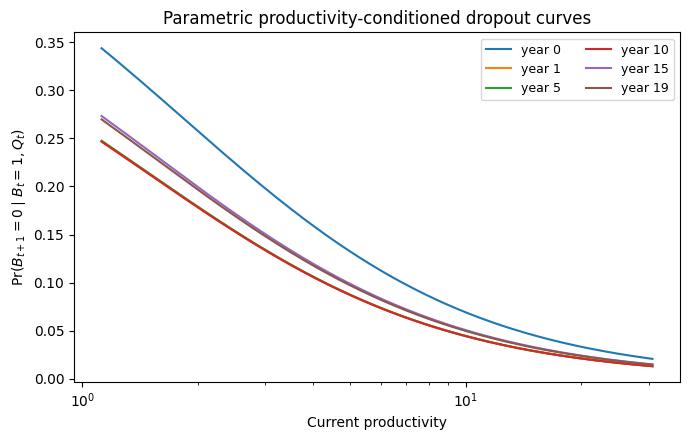

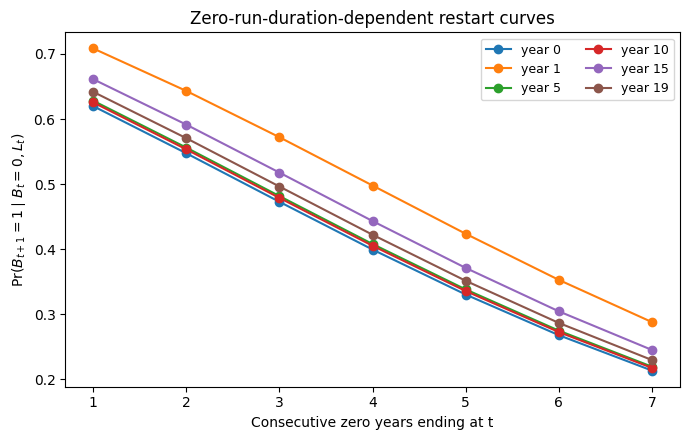

In [9]:
# Cell 6A: fit param prod-conditioned dropout and zero-duration restart

active_dropout_fit = trans.loc[
    (trans["state"] == 1) &
    trans["pubs_adj"].notna() &
    trans["next_state"].notna() &
    trans["CareerAge"].between(0, Y - 1),
    ["CareerAge", "pubs_adj", "next_state"]
].copy()

active_dropout_fit["drops_to_zero"] = (active_dropout_fit["next_state"] == 0).astype(int)
active_dropout_fit["log1p_q"] = np.log1p(active_dropout_fit["pubs_adj"].clip(lower=0))

year_idx = active_dropout_fit["CareerAge"].astype(int).to_numpy()
x_log1p_q = active_dropout_fit["log1p_q"].to_numpy(dtype=float)
y_drop = active_dropout_fit["drops_to_zero"].to_numpy(dtype=float)


def sigmoid_stable(x):
    x = np.clip(np.asarray(x, dtype=float), -35, 35)
    return 1 / (1 + np.exp(-x))


def logit_clipped(p):
    p = np.clip(p, MIN_PROB, MAX_PROB)
    return np.log(p / (1 - p))


initial_intercepts = []
for year in range(Y):
    g = active_dropout_fit.loc[active_dropout_fit["CareerAge"] == year]
    raw_rate = g["drops_to_zero"].mean() if len(g) > 0 else y_drop.mean()
    initial_intercepts.append(logit_clipped(raw_rate))

initial_intercepts = np.asarray(initial_intercepts, dtype=float)
initial_log_gamma = np.log(0.25)
initial_theta = np.r_[initial_intercepts, initial_log_gamma]


def dropout_neg_log_likelihood(theta):
    intercepts = theta[:Y]
    gamma = np.exp(theta[Y])

    eta = intercepts[year_idx] - gamma * x_log1p_q
    p_drop = sigmoid_stable(eta)

    nll = -np.sum(
        y_drop * np.log(np.clip(p_drop, MIN_PROB, MAX_PROB)) +
        (1 - y_drop) * np.log(np.clip(1 - p_drop, MIN_PROB, MAX_PROB))
    )
    return nll


bounds = [(-10, 10)] * Y + [(np.log(1e-6), np.log(25.0))]
opt = minimize(
    dropout_neg_log_likelihood,
    initial_theta,
    method="L-BFGS-B",
    bounds=bounds,
)

if not opt.success:
    print("WARNING: bad converge")
    print(opt.message)

fitted_intercepts = opt.x[:Y]
fitted_gamma = float(np.exp(opt.x[Y]))


def predict_dropout_prob(q, year):
    q = np.asarray(q, dtype=float)
    year_arr = np.asarray(year, dtype=int)
    eta = fitted_intercepts[year_arr] - fitted_gamma * np.log1p(np.clip(q, 0, None))
    return np.clip(sigmoid_stable(eta), MIN_PROB, MAX_PROB)


q_ref = active_dropout_fit["pubs_adj"].quantile([0.25, 0.50, 0.75, 0.95]).to_dict()

dropout_param_rows = []
for year in range(Y):
    g = active_dropout_fit.loc[active_dropout_fit["CareerAge"] == year]
    observed_dropout_rate = g["drops_to_zero"].mean() if len(g) > 0 else np.nan
    dropout_param_rows.append({
        "year": year,
        "n_active_transitions": len(g),
        "observed_dropout_rate": observed_dropout_rate,
        "dropout_intercept": fitted_intercepts[year],
        "dropout_gamma_log1p_q": fitted_gamma,
        "pred_drop_q25": predict_dropout_prob(q_ref[0.25], year),
        "pred_drop_q50": predict_dropout_prob(q_ref[0.50], year),
        "pred_drop_q75": predict_dropout_prob(q_ref[0.75], year),
        "pred_drop_q95": predict_dropout_prob(q_ref[0.95], year),
    })

dropout_param_summary = pd.DataFrame(dropout_param_rows)

restart_fit = trans.loc[
    (trans["state"] == 0) &
    trans["next_state"].notna() &
    trans["CareerAge"].between(0, Y - 1),
    ["CareerAge", "next_state", "zero_run_length"]
].copy()

restart_fit["restarts"] = (restart_fit["next_state"] == 1).astype(int)
restart_fit["zero_run_length"] = restart_fit["zero_run_length"].clip(lower=1).astype(int)
restart_fit["zero_run_excess"] = restart_fit["zero_run_length"] - 1

restart_year_idx = restart_fit["CareerAge"].astype(int).to_numpy()
x_zero_run_excess = restart_fit["zero_run_excess"].to_numpy(dtype=float)
y_restart = restart_fit["restarts"].to_numpy(dtype=float)

restart_initial_intercepts = []
for year in range(Y):
    g = restart_fit.loc[restart_fit["CareerAge"] == year]
    raw_rate = g["restarts"].mean() if len(g) > 0 else y_restart.mean()
    restart_initial_intercepts.append(logit_clipped(raw_rate))

restart_initial_intercepts = np.asarray(restart_initial_intercepts, dtype=float)
restart_initial_log_rho = np.log(0.25)
restart_initial_theta = np.r_[restart_initial_intercepts, restart_initial_log_rho]


def restart_neg_log_likelihood(theta):
    intercepts = theta[:Y]
    rho = np.exp(theta[Y])

    eta = intercepts[restart_year_idx] - rho * x_zero_run_excess
    p_restart = sigmoid_stable(eta)

    nll = -np.sum(
        y_restart * np.log(np.clip(p_restart, MIN_PROB, MAX_PROB)) +
        (1 - y_restart) * np.log(np.clip(1 - p_restart, MIN_PROB, MAX_PROB))
    )
    return nll


restart_bounds = [(-10, 10)] * Y + [(np.log(1e-6), np.log(25.0))]
restart_opt = minimize(
    restart_neg_log_likelihood,
    restart_initial_theta,
    method="L-BFGS-B",
    bounds=restart_bounds,
)

if not restart_opt.success:
    print("WARNING: bad converge")
    print(restart_opt.message)

fitted_restart_intercepts = restart_opt.x[:Y]
fitted_restart_rho = float(np.exp(restart_opt.x[Y]))


def predict_restart_prob(zero_run_length, year):
    zero_run_length = np.asarray(zero_run_length, dtype=float)
    year_arr = np.asarray(year, dtype=int)
    zero_run_excess = np.clip(zero_run_length - 1, 0, None)
    eta = fitted_restart_intercepts[year_arr] - fitted_restart_rho * zero_run_excess
    return np.clip(sigmoid_stable(eta), MIN_PROB, MAX_PROB)


restart_param_rows = []
for year in range(Y):
    g = restart_fit.loc[restart_fit["CareerAge"] == year]
    observed_restart_rate = g["restarts"].mean() if len(g) > 0 else np.nan
    restart_param_rows.append({
        "year": year,
        "n_zero_transitions": len(g),
        "observed_restart_rate": observed_restart_rate,
        "restart_intercept": fitted_restart_intercepts[year],
        "restart_rho_zero_run_excess": fitted_restart_rho,
        "pred_restart_run1": predict_restart_prob(1, year),
        "pred_restart_run2": predict_restart_prob(2, year),
        "pred_restart_run3": predict_restart_prob(3, year),
        "pred_restart_run5": predict_restart_prob(5, year),
    })

restart_param_summary = pd.DataFrame(restart_param_rows)

print("logistic dropout model")
print(f"Converged: {opt.success}")
print(f"Negative log-likelihood: {opt.fun:.3f}")
print(f"Fitted gamma on log(1 + Q_t): {fitted_gamma:.4f}")
print()
display(dropout_param_summary.round(4))
print()
print("Zero-run-duration-dependent restart model")
print(f"Converged: {restart_opt.success}")
print(f"Negative log-likelihood: {restart_opt.fun:.3f}")
print(f"Fitted rho on zero-run excess: {fitted_restart_rho:.4f}")
print()
display(restart_param_summary.round(4))

q_grid = np.linspace(
    active_dropout_fit["pubs_adj"].quantile(0.01),
    active_dropout_fit["pubs_adj"].quantile(0.99),
    300,
)
q_grid = np.clip(q_grid, MIN_POS_Q, None)

fig, ax = plt.subplots(figsize=(7, 4.5))
for year in [0, 1, 5, 10, 15, 19]:
    ax.plot(
        q_grid,
        predict_dropout_prob(q_grid, year),
        label=f"year {year}")

ax.set_xscale("log")
ax.set_xlabel("Current productivity")
ax.set_ylabel(r"Pr($B_{t+1}=0 \mid B_t=1, Q_t$)")
ax.set_title("Parametric productivity-conditioned dropout curves")
ax.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_paramDropoutCurves.png", dpi=300, bbox_inches="tight")
plt.show()

run_grid = np.arange(1, 8)
fig, ax = plt.subplots(figsize=(7, 4.5))
for year in [0, 1, 5, 10, 15, 19]:
    ax.plot(
        run_grid,
        predict_restart_prob(run_grid, year),
        marker="o",
        label=f"year {year}")

ax.set_xlabel("Consecutive zero years ending at t")
ax.set_ylabel(r"Pr($B_{t+1}=1 \mid B_t=0, L_t$)")
ax.set_title("Zero-run-duration-dependent restart curves")
ax.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_restartDurationCurves.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
# Cell 6B: fit positive-only yearwise log AR(1)

positive_ar1_fit = working_df_fit[(working_df_fit["pubs_adj"] > 0) & (working_df_fit["pubs_adj_next"] > 0)].copy()
positive_ar1_fit["log_pubs_pos"] = np.log(positive_ar1_fit["pubs_adj"])
positive_ar1_fit["log_pubs_pos_next"] = np.log(positive_ar1_fit["pubs_adj_next"])

def fit_positive_log_ar1(subset):
    x = subset["log_pubs_pos"].to_numpy()
    y = subset["log_pubs_pos_next"].to_numpy()

    if len(x) < 3:
        return {
            "n": len(x),
            "intercept": np.nan,
            "beta": np.nan,
            "sigma_resid": np.nan,
            "var_resid": np.nan,
            "implied_stationary_mean_log": np.nan,
            "implied_stationary_var_log": np.nan,
            "mean_resid": np.nan,
            "sd_resid": np.nan,}

    X = np.column_stack([np.ones(len(x)), x])

    intercept, beta = np.linalg.lstsq(X, y, rcond=None)[0]

    y_hat = intercept + beta * x
    resid = y - y_hat

    sigma = np.sqrt(np.mean(resid**2))
    var = sigma**2

    if abs(beta) < 1:
        implied_mean = intercept / (1 - beta)
        implied_var = var / (1 - beta**2)
    else:
        implied_mean = np.nan
        implied_var = np.nan

    return {
        "n": len(x),
        "intercept": intercept,
        "beta": beta,
        "sigma_resid": sigma,
        "var_resid": var,
        "implied_stationary_mean_log": implied_mean,
        "implied_stationary_var_log": implied_var,
        "mean_resid": resid.mean(),
        "sd_resid": resid.std(ddof=0),}


global_ar1_params = pd.DataFrame([{"model": "global_positive", **fit_positive_log_ar1(positive_ar1_fit)}])

year_ar1_rows = []

for year in range(Y):
    subset = positive_ar1_fit[positive_ar1_fit["CareerAge"] == year].copy()
    year_ar1_rows.append({"year": year, **fit_positive_log_ar1(subset)})

year_ar1_params = pd.DataFrame(year_ar1_rows)

print("Global positive-only AR(1)")
display(global_ar1_params)

print("Yearwise positive-only AR(1)")
display(year_ar1_params)

print("problematic abs beta >= 1")
display(year_ar1_params.loc[year_ar1_params["beta"].abs() >= 1])


Global positive-only AR(1)


,model,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,global_positive,26499,0.706327,0.597931,0.646869,0.41844,1.75673,0.65129,-2.150478e-16,0.646869


Yearwise positive-only AR(1)


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,0,1365,0.819365,0.487050,0.659691,0.435192,1.597357,0.570532,-2.931314e-16,0.659691
1,1,1524,1.012746,0.480930,0.632968,0.400649,1.951079,0.521199,-7.960969e-16,0.632968
2,2,1738,0.883562,0.565076,0.635208,0.403490,2.031531,0.592766,-4.497106e-17,0.635208
3,3,1825,0.864084,0.564572,0.626882,0.392981,1.984447,0.576845,9.616661e-16,0.626882
4,4,1846,0.861894,0.565928,0.611380,0.373786,1.985604,0.549907,-5.032690e-16,0.611380
5,5,1792,0.762904,0.571968,0.635388,0.403717,1.782353,0.600009,7.335402e-17,0.635388
6,6,1733,0.688805,0.599914,0.628445,0.394943,1.721643,0.616999,-5.289095e-16,0.628445
7,7,1634,0.672751,0.599344,0.651036,0.423848,1.679121,0.661448,-8.283867e-16,0.651036
8,8,1563,0.695445,0.591099,0.641449,0.411457,1.700767,0.632424,2.312787e-16,0.641449
9,9,1483,0.641599,0.618118,0.652205,0.425371,1.680096,0.688380,4.012674e-17,0.652205


problematic abs beta >= 1


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid


In [11]:
# Cell 7A: fit init gamma and restart exponential


q0_empirical = working_df.loc[working_df["CareerAge"] == 0, "pubs_adj"].dropna()
q0_pos_empirical = q0_empirical[q0_empirical > 0]

p_init_active = (q0_empirical > 0).mean()

gamma_q0_shape, gamma_q0_loc, gamma_q0_scale = stats.gamma.fit(q0_pos_empirical, floc=0)
gamma_q0_rate = 1 / gamma_q0_scale
gamma_q0_mean = gamma_q0_shape * gamma_q0_scale

restart_q_empirical = trans.loc[
    (trans["state"] == 0) & (trans["next_state"] == 1),
    "pubs_adj_next"
].dropna()
restart_q_empirical = restart_q_empirical[restart_q_empirical > 0]

alpha_restart = restart_q_empirical.mean()
lambda_restart = 1 / alpha_restart

print("Initial active probability:", p_init_active)
print("Initial positive Gamma shape:", gamma_q0_shape)
print("Initial positive Gamma scale:", gamma_q0_scale)
print("Initial positive Gamma rate:", gamma_q0_rate)
print("Initial positive Gamma implied mean:", gamma_q0_mean)
print()
print("Restart exponential scale alpha:", alpha_restart)
print("Restart exponential rate lambda:", lambda_restart)
print("Empirical restart n:", len(restart_q_empirical))
print()
print("Initial positive productivity empirical summary:")
print(q0_pos_empirical.describe())
print()
print("Restart magnitude empirical summary:")
print(restart_q_empirical.describe())


Initial active probability: 0.7902368293861769
Initial positive Gamma shape: 2.15167023161791
Initial positive Gamma scale: 2.531674038263246
Initial positive Gamma rate: 0.3949955582299252
Initial positive Gamma implied mean: 5.4473276642909285

Restart exponential scale alpha: 4.299784306131943
Restart exponential rate lambda: 0.23256980555371004
Empirical restart n: 3061

Initial positive productivity empirical summary:
count    1635.000000
mean        5.447328
std         4.619311
min         1.231551
25%         2.625676
50%         4.207789
75%         6.945516
max        74.304910
Name: pubs_adj, dtype: float64

Restart magnitude empirical summary:
count    3061.000000
mean        4.299784
std         3.505162
min         1.058909
25%         1.951028
50%         3.225469
75%         5.411175
max        30.222393
Name: pubs_adj_next, dtype: float64


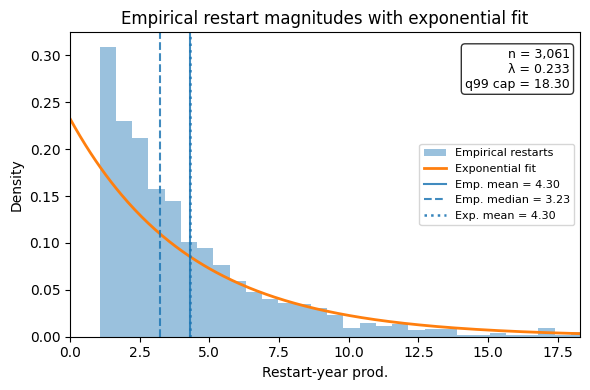

In [12]:
# Cell 7B: restart dx check

restart_q_empirical = pd.Series(restart_q_empirical).dropna()
restart_q_empirical = restart_q_empirical[restart_q_empirical > 0]

n_restart = len(restart_q_empirical)
emp_mean_restart = restart_q_empirical.mean()
emp_median_restart = restart_q_empirical.median()
exp_mean_restart = 1 / lambda_restart

x_max = np.quantile(restart_q_empirical, 0.99)
x_grid = np.linspace(0, x_max, 300)
restart_pdf = lambda_restart * np.exp(-lambda_restart * x_grid)

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(restart_q_empirical,bins=50,density=True,alpha=0.45,label="Empirical restarts")
ax.plot(x_grid,restart_pdf,linewidth=2,label="Exponential fit")
ax.axvline(emp_mean_restart,linestyle="solid",linewidth=1.5,alpha=0.85,label=f"Emp. mean = {emp_mean_restart:.2f}")
ax.axvline(emp_median_restart,linestyle="dashed",linewidth=1.5,alpha=0.85,label=f"Emp. median = {emp_median_restart:.2f}")
ax.axvline(exp_mean_restart,linestyle="dotted",linewidth=1.8,alpha=0.9,label=f"Exp. mean = {exp_mean_restart:.2f}")

ax.text(0.98,0.95,f"n = {n_restart:,}\nλ = {lambda_restart:.3f}\nq99 cap = {x_max:.2f}",transform=ax.transAxes,ha="right",va="top",fontsize=9,bbox=dict(boxstyle="round",facecolor="white",alpha=0.8))
ax.set_xlim(0, x_max)
ax.set_xlabel("Restart-year prod.")
ax.set_ylabel("Density")
ax.set_title("Empirical restart magnitudes with exponential fit")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_restartFit.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
# Cell 7C: empirical restart magnitude function dx

restart_mag_fit = trans.loc[
    (trans["state"] == 0) &
    (trans["next_state"] == 1) &
    trans["CareerAge"].between(0, Y - 1),
    ["CareerAge", "career_stage", "zero_run_length", "pubs_adj_next"]
].copy()

restart_mag_fit = restart_mag_fit.rename(columns={"pubs_adj_next": "q_restart"})
restart_mag_fit = restart_mag_fit.dropna(subset=["q_restart", "zero_run_length"])
restart_mag_fit = restart_mag_fit[restart_mag_fit["q_restart"] > 0].copy()

restart_mag_fit["zero_run_length"] = restart_mag_fit["zero_run_length"].clip(lower=1).astype(int)
restart_mag_fit["zero_run_excess"] = restart_mag_fit["zero_run_length"] - 1
restart_mag_fit["year_scaled"] = restart_mag_fit["CareerAge"] / Y
restart_mag_fit["stage_idx"] = pd.Categorical(
    restart_mag_fit["career_stage"],
    categories=stage_order,
    ordered=True
).codes

restart_mag_summary_stage = (
    restart_mag_fit
    .groupby("career_stage")
    .agg(
        n=("q_restart", "size"),
        mean_restart=("q_restart", "mean"),
        median_restart=("q_restart", "median"),
        q01_restart=("q_restart", lambda x: x.quantile(0.01)),
        q25_restart=("q_restart", lambda x: x.quantile(0.25)),
        q75_restart=("q_restart", lambda x: x.quantile(0.75)),
        q90_restart=("q_restart", lambda x: x.quantile(0.90)),
        q95_restart=("q_restart", lambda x: x.quantile(0.95)),
        mean_zero_run=("zero_run_length", "mean"),
    )
    .reindex(stage_order)
    .reset_index()
)

restart_mag_summary_year = (
    restart_mag_fit
    .groupby("CareerAge")
    .agg(
        n=("q_restart", "size"),
        mean_restart=("q_restart", "mean"),
        median_restart=("q_restart", "median"),
        q75_restart=("q_restart", lambda x: x.quantile(0.75)),
        q90_restart=("q_restart", lambda x: x.quantile(0.90)),
        q95_restart=("q_restart", lambda x: x.quantile(0.95)),
        mean_zero_run=("zero_run_length", "mean"),
    )
    .reset_index()
)

display(restart_mag_summary_stage.round(3))
display(restart_mag_summary_year.round(3))

,career_stage,n,mean_restart,median_restart,q01_restart,q25_restart,q75_restart,q90_restart,q95_restart,mean_zero_run
0,0-4,1086,4.992,3.902,1.188,2.463,6.451,9.687,12.117,1.344
1,5-7,449,4.853,3.600,1.090,2.118,6.044,9.771,12.262,1.653
2,8-13,846,3.901,2.914,1.059,1.822,4.654,7.573,9.687,1.708
3,14-20,680,3.326,2.524,1.059,1.502,4.070,6.634,8.364,2.059


,CareerAge,n,mean_restart,median_restart,q75_restart,q90_restart,q95_restart,mean_zero_run
0,0,269,4.225,3.229,5.411,8.166,9.728,1.000
1,1,296,5.034,3.902,6.644,9.312,12.114,1.297
2,2,206,5.245,4.353,6.451,10.098,13.251,1.515
3,3,160,5.495,4.296,7.286,11.111,14.520,1.644
4,4,155,5.383,4.208,7.236,10.855,12.395,1.497
5,5,144,5.886,3.990,8.213,12.080,16.737,1.660
6,6,155,4.723,3.581,6.044,9.563,12.141,1.652
7,7,150,3.995,3.320,4.874,6.833,8.672,1.647
8,8,163,4.124,3.229,4.885,7.545,10.575,1.675
9,9,134,4.109,2.990,5.041,7.622,10.131,1.716


In [14]:
# Cell 8: simulation helpers


def make_ar1_year_lookup(year_ar1_params):
    return (year_ar1_params
        .set_index("year")[["intercept", "beta", "sigma_resid"]].to_dict("index"))

ar1_year_lookup = make_ar1_year_lookup(year_ar1_params)


def draw_exponential_positive(scale, size, rng):
    if size == 0:
        return np.array([], dtype=float)
    return np.clip(rng.exponential(scale=scale, size=size), MIN_POS_Q, None)


def draw_gamma_positive(shape, scale, size, rng):
    if size == 0:
        return np.array([], dtype=float)
    return np.clip(rng.gamma(shape=shape, scale=scale, size=size), MIN_POS_Q, None)


def draw_next_binary_state_parametric(q_current, b_current, zero_run_length_current, year, rng):

    q_current = np.asarray(q_current, dtype=float)
    b_current = np.asarray(b_current, dtype=int)
    zero_run_length_current = np.asarray(zero_run_length_current, dtype=int)
    p_to_active = np.zeros(len(b_current), dtype=float)

    currently_zero = b_current == 0
    currently_active = b_current == 1

    if currently_zero.any():
        p_to_active[currently_zero] = predict_restart_prob(
            zero_run_length_current[currently_zero],
            year
        )

    if currently_active.any():
        p_drop = predict_dropout_prob(q_current[currently_active], year)
        p_to_active[currently_active] = 1 - p_drop

    p_to_active = np.clip(p_to_active, MIN_PROB, MAX_PROB)
    return rng.binomial(1, p_to_active, size=len(b_current)).astype(int)


def simulate_parametric_productivity_conditioned_hurdle(
    ar1_year_lookup,
    gamma_q0_shape=gamma_q0_shape,
    gamma_q0_scale=gamma_q0_scale,
    alpha_restart=alpha_restart,
    p_init_active=p_init_active,
    Y=Y,
    n=N,
    rng=None):

    if rng is None:
        rng = np.random.default_rng()

    trajectories = np.zeros((Y + 1, n), dtype=float)
    z_paths = np.full((Y + 1, n), np.nan, dtype=float)
    b_paths = np.zeros((Y + 1, n), dtype=int)
    zero_run_paths = np.zeros((Y + 1, n), dtype=int)

    b_paths[0] = rng.binomial(1, p_init_active, size=n).astype(int)
    init_active = b_paths[0] == 1
    q0 = np.zeros(n)
    q0[init_active] = draw_gamma_positive(gamma_q0_shape, gamma_q0_scale, init_active.sum(), rng)

    trajectories[0] = q0
    z_paths[0, init_active] = np.log(q0[init_active])
    zero_run_paths[0, ~init_active] = 1

    for t in range(Y):
        q_now = trajectories[t]
        b_now = b_paths[t]
        zero_run_now = zero_run_paths[t]
        b_next = draw_next_binary_state_parametric(
            q_current=q_now,
            b_current=b_now,
            zero_run_length_current=zero_run_now,
            year=t,
            rng=rng)

        q_next = np.zeros(n)
        z_next = np.full(n, np.nan)
        zero_run_next = np.zeros(n, dtype=int)

        restart = (b_now == 0) & (b_next == 1)
        continued = (b_now == 1) & (b_next == 1)
        stay_zero = (b_now == 0) & (b_next == 0)
        new_zero = (b_now == 1) & (b_next == 0)

        if restart.sum() > 0:
            q_restart = draw_exponential_positive(alpha_restart, restart.sum(), rng)
            q_next[restart] = q_restart
            z_next[restart] = np.log(q_restart)

        if continued.sum() > 0:
            intercept = ar1_year_lookup[t]["intercept"]
            beta = ar1_year_lookup[t]["beta"]
            sigma = ar1_year_lookup[t]["sigma_resid"]
            shock = rng.normal(loc=0, scale=sigma, size=continued.sum())
            z_cont = intercept + beta * z_paths[t, continued] + shock

            q_next[continued] = np.exp(z_cont)
            z_next[continued] = z_cont

        zero_run_next[stay_zero] = zero_run_now[stay_zero] + 1
        zero_run_next[new_zero] = 1
        zero_run_next[restart | continued] = 0

        trajectories[t + 1] = q_next
        z_paths[t + 1] = z_next
        b_paths[t + 1] = b_next
        zero_run_paths[t + 1] = zero_run_next

    return trajectories, z_paths, b_paths, zero_run_paths


def simulate_combined_model(ar1_year_lookup, n=N, Y=Y, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return simulate_parametric_productivity_conditioned_hurdle(
        ar1_year_lookup=ar1_year_lookup,
        gamma_q0_shape=gamma_q0_shape,
        gamma_q0_scale=gamma_q0_scale,
        alpha_restart=alpha_restart,
        p_init_active=p_init_active,
        Y=Y,
        n=n,
        rng=rng)


def trajectories_to_dataframe_combined(trajs, b_paths, zero_run_paths=None):
    years = np.arange(trajs.shape[0])
    ix = np.arange(trajs.shape[1])

    df_sim = pd.DataFrame({
        "CareerAge": np.repeat(years, len(ix)),
        "ix": np.tile(ix, len(years)),
        "pubs_adj": trajs.reshape(-1),
        "state": b_paths.reshape(-1),})

    if zero_run_paths is not None:
        df_sim["zero_run_length"] = zero_run_paths.reshape(-1)

    df_sim["pubs_adj_next"] = df_sim.groupby("ix")["pubs_adj"].shift(-1)
    df_sim["state_next"] = df_sim.groupby("ix")["state"].shift(-1)
    if zero_run_paths is not None:
        df_sim["zero_run_length_next"] = df_sim.groupby("ix")["zero_run_length"].shift(-1)
    df_sim["q_adj_delta"] = df_sim["pubs_adj_next"] - df_sim["pubs_adj"]
    df_sim["log_pubs_adj"] = np.where(df_sim["pubs_adj"] > 0, np.log(df_sim["pubs_adj"]), np.nan)
    df_sim["log_pubs_next"] = np.where(df_sim["pubs_adj_next"] > 0, np.log(df_sim["pubs_adj_next"]), np.nan)
    df_sim["log_delta"] = df_sim["log_pubs_next"] - df_sim["log_pubs_adj"]

    return df_sim.dropna(subset=["pubs_adj_next", "state_next"]).copy()


In [15]:
# Cell 7D: fit simple parametric restart magnitude functions

q_restart = restart_mag_fit["q_restart"].to_numpy(dtype=float)
year_scaled = restart_mag_fit["year_scaled"].to_numpy(dtype=float)
stage_idx = restart_mag_fit["stage_idx"].to_numpy(dtype=int)
zero_run_x = np.log1p(restart_mag_fit["zero_run_excess"].to_numpy(dtype=float))

n_restart = len(q_restart)
n_stage = len(stage_order)

gamma_shape0, _, gamma_scale0 = stats.gamma.fit(q_restart, floc=0)
log_mean0 = np.log(q_restart.mean())
log_shape0 = np.log(gamma_shape0)

def restart_eta(theta, mean_model):
    if mean_model == "global":
        return np.full(n_restart, theta[0])

    if mean_model == "year_linear":
        return theta[0] + theta[1] * year_scaled

    if mean_model == "stage":
        return theta[stage_idx]

    if mean_model == "stage_zr":
        rho = np.exp(theta[n_stage])
        return theta[:n_stage][stage_idx] - rho * zero_run_x

    raise ValueError(mean_model)

def restart_nll(theta, dist, mean_model):
    eta = restart_eta(theta[:-1], mean_model) if dist == "gamma" else restart_eta(theta, mean_model)
    mean = np.exp(np.clip(eta, -20, 20))

    if dist == "exponential":
        return np.sum(np.log(mean) + q_restart / mean)

    if dist == "gamma":
        shape = np.exp(theta[-1])
        scale = mean / shape
        return -np.sum(stats.gamma.logpdf(q_restart, a=shape, loc=0, scale=scale))

    raise ValueError(dist)

def restart_initial_theta(dist, mean_model):
    if mean_model == "global":
        theta = np.array([log_mean0])

    elif mean_model == "year_linear":
        theta = np.array([log_mean0, -0.25])

    elif mean_model == "stage":
        stage_means = (
            restart_mag_fit
            .groupby("career_stage")["q_restart"]
            .mean()
            .reindex(stage_order)
            .fillna(q_restart.mean())
        )
        theta = np.log(stage_means.to_numpy())

    elif mean_model == "stage_zr":
        stage_means = (
            restart_mag_fit
            .groupby("career_stage")["q_restart"]
            .mean()
            .reindex(stage_order)
            .fillna(q_restart.mean())
        )
        theta = np.r_[np.log(stage_means.to_numpy()), np.log(0.10)]

    else:
        raise ValueError(mean_model)

    if dist == "gamma":
        theta = np.r_[theta, log_shape0]

    return theta

def restart_bounds(dist, mean_model):
    if mean_model == "global":
        bounds = [(-10, 10)]

    elif mean_model == "year_linear":
        bounds = [(-10, 10), (-10, 10)]

    elif mean_model == "stage":
        bounds = [(-10, 10)] * n_stage

    elif mean_model == "stage_zr":
        bounds = [(-10, 10)] * n_stage + [(np.log(1e-6), np.log(25.0))]

    else:
        raise ValueError(mean_model)

    if dist == "gamma":
        bounds = bounds + [(np.log(0.15), np.log(50.0))]

    return bounds

def restart_mean_from_fit(theta, dist, mean_model):
    eta = restart_eta(theta[:-1], mean_model) if dist == "gamma" else restart_eta(theta, mean_model)
    return np.exp(np.clip(eta, -20, 20))

def restart_cdf_from_fit(theta, dist, mean_model):
    mean = restart_mean_from_fit(theta, dist, mean_model)

    if dist == "exponential":
        return stats.expon.cdf(q_restart, loc=0, scale=mean)

    if dist == "gamma":
        shape = np.exp(theta[-1])
        return stats.gamma.cdf(q_restart, a=shape, loc=0, scale=mean / shape)

    raise ValueError(dist)

restart_specs = [
    ("exp_global", "exponential", "global"),
    ("exp_year_linear", "exponential", "year_linear"),
    ("exp_stage", "exponential", "stage"),
    ("exp_stage_zr", "exponential", "stage_zr"),
    ("gamma_global", "gamma", "global"),
    ("gamma_year_linear", "gamma", "year_linear"),
    ("gamma_stage", "gamma", "stage"),
    ("gamma_stage_zr", "gamma", "stage_zr"),
]

restart_model_fits = {}

restart_fit_rows = []
for name, dist, mean_model in restart_specs:
    theta0 = restart_initial_theta(dist, mean_model)
    opt = minimize(
        restart_nll,
        theta0,
        args=(dist, mean_model),
        method="L-BFGS-B",
        bounds=restart_bounds(dist, mean_model),
    )

    if not opt.success:
        print(f"WARNING: {name} bad converge: {opt.message}")

    nll = restart_nll(opt.x, dist, mean_model)
    k = len(opt.x)
    aic = 2 * k + 2 * nll
    bic = k * np.log(n_restart) + 2 * nll

    pit = np.clip(restart_cdf_from_fit(opt.x, dist, mean_model), MIN_PROB, MAX_PROB)
    pit_ks = stats.kstest(pit, "uniform").statistic

    restart_model_fits[name] = {
        "theta": opt.x,
        "dist": dist,
        "mean_model": mean_model,
        "nll": nll,
        "aic": aic,
        "bic": bic,
        "pit_ks": pit_ks,
    }

    restart_fit_rows.append({
        "model": name,
        "dist": dist,
        "mean_model": mean_model,
        "n_params": k,
        "n": n_restart,
        "nll": nll,
        "aic": aic,
        "bic": bic,
        "pit_ks": pit_ks,
    })

restart_function_summary = pd.DataFrame(restart_fit_rows).sort_values("aic")
display(restart_function_summary.round(3))

restart_function_summary.to_csv(
    RESULTS / f"{MODEL_TAG}_restartFunctionSummary.csv",
    index=False
)

,model,dist,mean_model,n_params,n,nll,aic,bic,pit_ks
7,gamma_stage_zr,gamma,stage_zr,6,3061,7006.503,14025.007,14061.166,0.071
5,gamma_year_linear,gamma,year_linear,3,3061,7025.111,14056.222,14074.302,0.073
6,gamma_stage,gamma,stage,5,3061,7024.083,14058.166,14088.298,0.075
4,gamma_global,gamma,global,2,3061,7112.859,14229.717,14241.770,0.084
3,exp_stage_zr,exponential,stage_zr,5,3061,7477.246,14964.493,14994.625,0.207
1,exp_year_linear,exponential,year_linear,2,3061,7485.507,14975.015,14987.068,0.210
2,exp_stage,exponential,stage,4,3061,7485.049,14978.097,15002.203,0.211
0,exp_global,exponential,global,1,3061,7525.667,15053.334,15059.361,0.218


In [16]:
# Cell 9: simulate combined hurdle AR(1)

trajs_combined, z_trajs_combined, b_trajs_combined, zero_run_trajs_combined = simulate_combined_model(
    ar1_year_lookup=ar1_year_lookup,
    n=N,
    Y=Y,
    rng=rng)

trajs = trajs_combined
b_trajs = b_trajs_combined

df_trajs = trajectories_to_dataframe_combined(trajs, b_trajs, zero_run_trajs_combined)

print("trajectory array shape:", trajs.shape)
print("binary path array shape:", b_trajs.shape)
print("zero-run path array shape:", zero_run_trajs_combined.shape)
print()
print("sim'd state fractions:")
for t in [0, 5, 10, 15, 20]:
    print(f"Year {t}: zero={(b_trajs[t] == 0).mean():.4f}, active={(b_trajs[t] == 1).mean():.4f}")

print()
print("sim'd positive log increments:")
print(df_trajs.loc[(df_trajs["state"] == 1) & (df_trajs["state_next"] == 1), "log_delta"].describe())
print()
print("sim'd zero-run length summary among zero states:")
print(df_trajs.loc[df_trajs["state"] == 0, "zero_run_length"].describe())


/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


trajectory array shape: (21, 50000)
binary path array shape: (21, 50000)
zero-run path array shape: (21, 50000)

sim'd state fractions:
Year 0: zero=0.2086, active=0.7914
Year 5: zero=0.1231, active=0.8769
Year 10: zero=0.1523, active=0.8477
Year 15: zero=0.1700, active=0.8300
Year 20: zero=0.1847, active=0.8153

sim'd positive log increments:
count    748479.000000
mean          0.014401
std           0.732889
min          -3.464003
25%          -0.479191
50%           0.007674
75%           0.500221
max           4.919577
Name: log_delta, dtype: float64

sim'd zero-run length summary among zero states:
count    160187.000000
mean          1.962893
std           2.023863
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          20.000000
Name: zero_run_length, dtype: float64


In [17]:
# Cell 7E: restart function stage diagnostics

restart_stage_rows = []

for name, fit in restart_model_fits.items():
    theta = fit["theta"]
    dist = fit["dist"]
    mean_model = fit["mean_model"]

    mean_hat = restart_mean_from_fit(theta, dist, mean_model)
    pit = np.clip(restart_cdf_from_fit(theta, dist, mean_model), MIN_PROB, MAX_PROB)

    for stage in stage_order:
        m = restart_mag_fit["career_stage"].eq(stage).to_numpy()
        x = q_restart[m]

        if len(x) == 0:
            continue

        restart_stage_rows.append({
            "model": name,
            "stage": stage,
            "n": len(x),
            "obs_mean": x.mean(),
            "fit_mean": mean_hat[m].mean(),
            "mean_resid": mean_hat[m].mean() - x.mean(),
            "obs_median": np.median(x),
            "pit_ks": stats.kstest(pit[m], "uniform").statistic,
            "obs_q90": np.quantile(x, 0.90),
            "obs_q95": np.quantile(x, 0.95),
        })

restart_function_stage_dx = pd.DataFrame(restart_stage_rows)
restart_function_stage_dx = restart_function_stage_dx.sort_values(["model", "stage"])

display(restart_function_stage_dx.round(3))

restart_function_stage_dx.to_csv(
    RESULTS / f"{MODEL_TAG}_restartFunctionStageDx.csv",
    index=False
)

,model,stage,n,obs_mean,fit_mean,mean_resid,obs_median,pit_ks,obs_q90,obs_q95
0,exp_global,0-4,1086,4.992,4.300,-0.692,3.902,0.232,9.687,12.117
3,exp_global,14-20,680,3.326,4.300,0.973,2.524,0.218,6.634,8.364
1,exp_global,5-7,449,4.853,4.300,-0.553,3.600,0.218,9.771,12.262
2,exp_global,8-13,846,3.901,4.300,0.399,2.914,0.218,7.573,9.687
8,exp_stage,0-4,1086,4.992,4.992,0.000,3.902,0.203,9.687,12.117
11,exp_stage,14-20,680,3.326,3.326,0.000,2.524,0.273,6.634,8.364
9,exp_stage,5-7,449,4.853,4.853,0.000,3.600,0.196,9.771,12.262
10,exp_stage,8-13,846,3.901,3.901,0.000,2.914,0.238,7.573,9.687
12,exp_stage_zr,0-4,1086,4.992,5.003,0.012,3.902,0.202,9.687,12.117
15,exp_stage_zr,14-20,680,3.326,3.319,-0.007,2.524,0.260,6.634,8.364


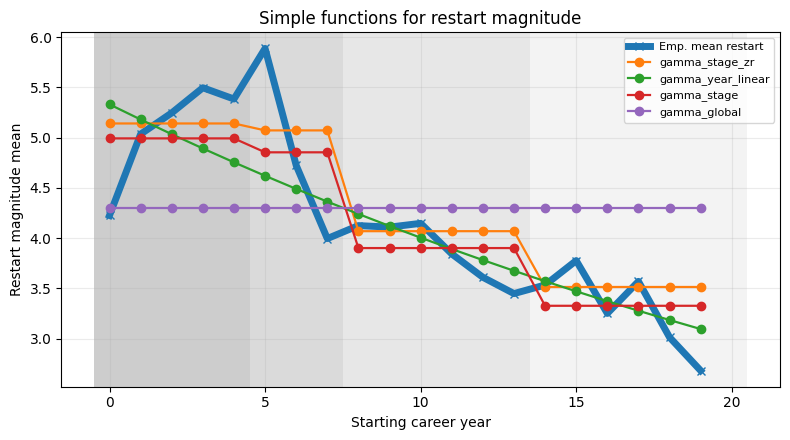

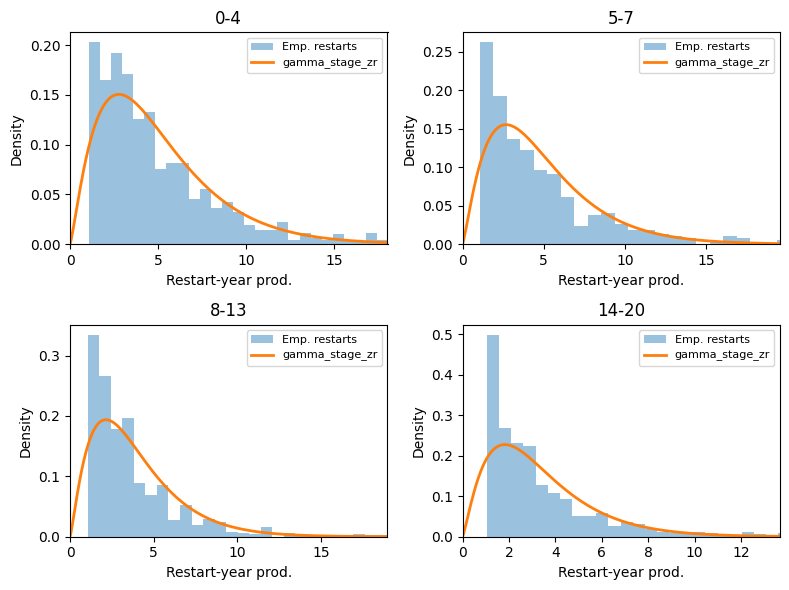

best restart function: gamma_stage_zr
{'theta': array([ 1.63704326,  1.62354183,  1.40326801,  1.25659333, -1.96831358,
        0.81735972]), 'dist': 'gamma', 'mean_model': 'stage_zr', 'nll': np.float64(7006.503433255784), 'aic': np.float64(14025.006866511569), 'bic': np.float64(14061.165848145241), 'pit_ks': np.float64(0.07123101430980189)}


In [18]:
# Cell 7F: plot restart function fits

top_restart_models = restart_function_summary.head(4)["model"].tolist()

year_grid = pd.DataFrame({"CareerAge": np.arange(Y)})
year_grid["career_stage"] = year_grid["CareerAge"].apply(assign_career_stage)
year_grid["year_scaled"] = year_grid["CareerAge"] / Y
year_grid["stage_idx"] = pd.Categorical(
    year_grid["career_stage"],
    categories=stage_order,
    ordered=True
).codes

median_zr_by_year = (
    restart_mag_fit
    .groupby("CareerAge")["zero_run_excess"]
    .median()
    .reindex(np.arange(Y))
    .fillna(restart_mag_fit["zero_run_excess"].median())
)

def restart_eta_grid(theta, mean_model):
    yg = year_grid["year_scaled"].to_numpy(dtype=float)
    sg = year_grid["stage_idx"].to_numpy(dtype=int)
    zg = np.log1p(median_zr_by_year.to_numpy(dtype=float))

    if mean_model == "global":
        return np.full(Y, theta[0])

    if mean_model == "year_linear":
        return theta[0] + theta[1] * yg

    if mean_model == "stage":
        return theta[sg]

    if mean_model == "stage_zr":
        rho = np.exp(theta[n_stage])
        return theta[:n_stage][sg] - rho * zg

    raise ValueError(mean_model)

fig, ax = plt.subplots(figsize=(8, 4.5))

for start, end, shade, label in stage_spans:
    ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

ax.plot(
    restart_mag_summary_year["CareerAge"],
    restart_mag_summary_year["mean_restart"],
    marker="x",
    linewidth=5,
    label="Emp. mean restart",
    zorder=3
)

for name in top_restart_models:
    fit = restart_model_fits[name]
    theta = fit["theta"]
    theta_mean = theta[:-1] if fit["dist"] == "gamma" else theta

    eta = restart_eta_grid(theta_mean, fit["mean_model"])
    mean_hat = np.exp(np.clip(eta, -20, 20))

    ax.plot(
        year_grid["CareerAge"],
        mean_hat,
        marker="o",
        linewidth=1.6,
        label=name,
        zorder=3
    )

ax.set_xlabel("Starting career year")
ax.set_ylabel("Restart magnitude mean")
ax.set_title("Simple functions for restart magnitude")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_restartFunctionMeanDx.png", dpi=300, bbox_inches="tight")
plt.show()


best_restart_model = restart_function_summary.iloc[0]["model"]
best_fit = restart_model_fits[best_restart_model]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()

for ax, stage in zip(axes, stage_order):
    sub = restart_mag_fit[restart_mag_fit["career_stage"] == stage]
    x = sub["q_restart"].to_numpy(dtype=float)

    if len(x) == 0:
        ax.set_title(stage)
        continue

    x_max = np.quantile(x, 0.99)
    xx = np.linspace(0, x_max, 300)

    ax.hist(x, bins=35, density=True, alpha=0.45, label="Emp. restarts")

    theta = best_fit["theta"]
    dist = best_fit["dist"]
    mean_model = best_fit["mean_model"]

    m = restart_mag_fit["career_stage"].eq(stage).to_numpy()
    mean_stage = restart_mean_from_fit(theta, dist, mean_model)[m]

    if dist == "exponential":
        yy = np.mean(stats.expon.pdf(xx[:, None], loc=0, scale=mean_stage[None, :]), axis=1)
    else:
        shape = np.exp(theta[-1])
        yy = np.mean(stats.gamma.pdf(xx[:, None], a=shape, loc=0, scale=mean_stage[None, :] / shape), axis=1)

    ax.plot(xx, yy, linewidth=2, label=best_restart_model)
    ax.set_title(stage)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("Restart-year prod.")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_restartFunctionBestStageFit.png", dpi=300, bbox_inches="tight")
plt.show()

print("best restart function:", best_restart_model)
print(restart_model_fits[best_restart_model])

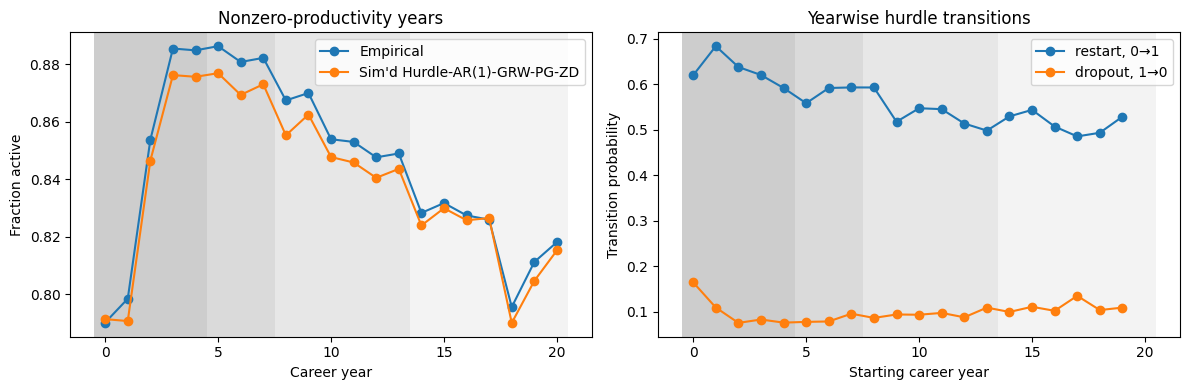

In [19]:
# Cell 10: binary path dx

emp_state_by_year = (
    df[df[age_col].between(0, Y)]
    .groupby(age_col)["state"]
    .agg(n="size", frac_active="mean")
    .reset_index()
    .rename(columns={age_col: "year"}))

sim_state_by_year = pd.DataFrame({
    "year": np.arange(Y + 1),
    "frac_active": b_trajs_combined.mean(axis=1),
    "frac_zero": 1 - b_trajs_combined.mean(axis=1),})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )

axes[0].plot(emp_state_by_year["year"], emp_state_by_year["frac_active"], marker="o", label="Empirical", zorder = 3)
axes[0].plot(sim_state_by_year["year"], sim_state_by_year["frac_active"], marker="o", label=f"Sim'd {MODEL_NAME}", zorder = 3)
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Fraction active")
axes[0].set_title("Nonzero-productivity years")
axes[0].legend()

axes[1].plot(year_transition_summary["year"], year_transition_summary["P_nothing_to_something"], marker="o", label="restart, 0→1", zorder = 3)
axes[1].plot(year_transition_summary["year"], year_transition_summary["P_something_to_nothing"], marker="o", label="dropout, 1→0", zorder = 3)
axes[1].set_xlabel("Starting career year")
axes[1].set_ylabel("Transition probability")
axes[1].set_title("Yearwise hurdle transitions")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_Dx.png", dpi=300, bbox_inches="tight")
plt.show()


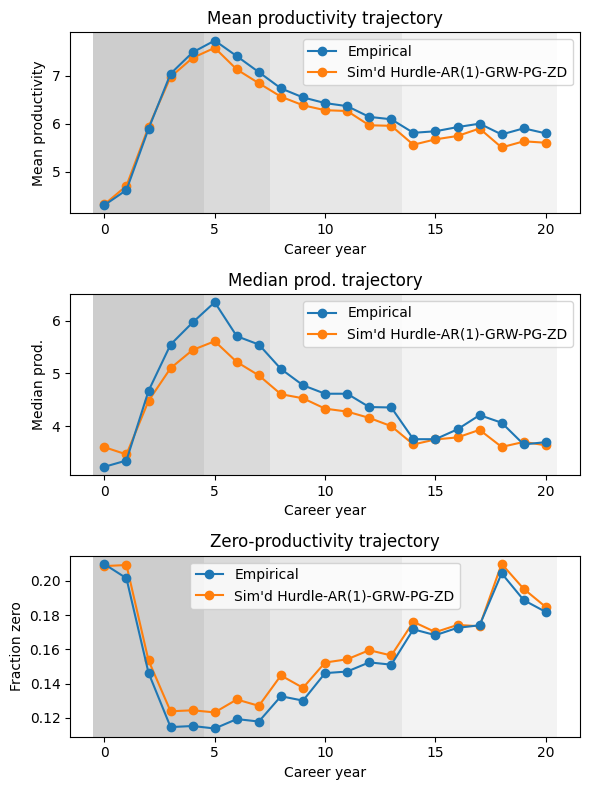

In [20]:
# Cell 11: canonical trajectory check

emp_mean = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .mean())

emp_median = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .median())

emp_frac_zero = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .apply(lambda x: (x == 0).mean()))

sim_mean = trajs_combined.mean(axis=1)
sim_median = np.median(trajs_combined, axis=1)
sim_frac_zero = (trajs_combined == 0).mean(axis=1)

years = np.arange(Y + 1)

fig, axes = plt.subplots(3, 1, figsize=(6, 8))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )

axes[0].plot(emp_mean.index, emp_mean.values, marker="o", label="Empirical", zorder = 3)
axes[0].plot(years, sim_mean, marker="o", label=f"Sim'd {MODEL_NAME}")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean productivity")
axes[0].set_title("Mean productivity trajectory")
axes[0].legend()

axes[1].plot(emp_median.index, emp_median.values, marker="o", label="Empirical", zorder = 3)
axes[1].plot(years, sim_median, marker="o", label=f"Sim'd {MODEL_NAME}")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Median prod.")
axes[1].set_title("Median prod. trajectory")
axes[1].legend()

axes[2].plot(emp_frac_zero.index, emp_frac_zero.values, marker="o", label="Empirical", zorder = 3)
axes[2].plot(years, sim_frac_zero, marker="o", label=f"Sim'd {MODEL_NAME}")
axes[2].set_xlabel("Career year")
axes[2].set_ylabel("Fraction zero")
axes[2].set_title("Zero-productivity trajectory")
axes[2].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_trajectories.png", dpi=300, bbox_inches="tight")

plt.show()


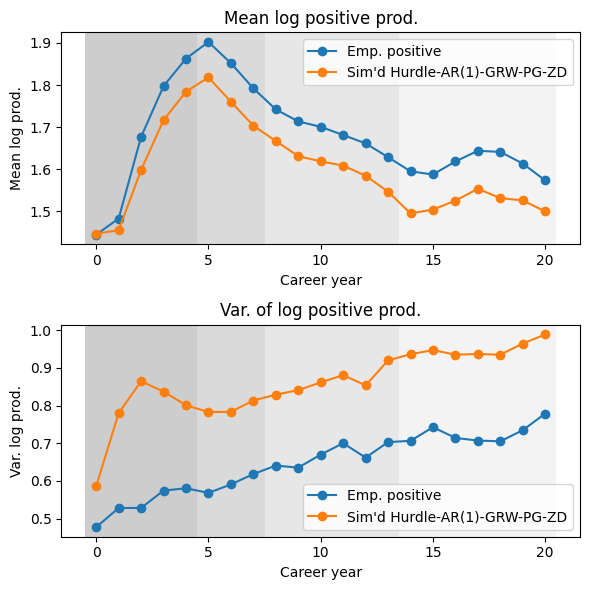

In [21]:
# Cell 12: yearwise log distrib dx

years = np.arange(0, Y + 1)

emp_year_stats = []
for t in years:
    subset = working_df[working_df["CareerAge"] == t]
    q = subset["pubs_adj"].dropna()

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    emp_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95),
    })

emp_year_stats = pd.DataFrame(emp_year_stats)

sim_year_stats = []
for t in years:
    q = pd.Series(trajs_combined[t])

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    sim_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95),
    })

sim_year_stats = pd.DataFrame(sim_year_stats)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )
axes[0].plot(
    emp_year_stats["year"],
    emp_year_stats["mean_log_prod_pos"],
    marker="o",
    label="Emp. positive", zorder = 3
)
axes[0].plot(
    sim_year_stats["year"],
    sim_year_stats["mean_log_prod_pos"],
    marker="o",
    label=f"Sim'd {MODEL_NAME}", zorder = 3
)
axes[0].set_title("Mean log positive prod.")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean log prod.")
axes[0].legend()

axes[1].plot(
    emp_year_stats["year"],
    emp_year_stats["var_log_prod_pos"],
    marker="o",
    label="Emp. positive", zorder = 3
)
axes[1].plot(
    sim_year_stats["year"],
    sim_year_stats["var_log_prod_pos"],
    marker="o",
    label=f"Sim'd {MODEL_NAME}", zorder = 3
)
axes[1].set_title("Var. of log positive prod.")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Var. log prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_posLog.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# Cell 13A: yearwise log-delta distrib dx func

def binned_mode(x, bins="auto"):
    x = pd.Series(x).dropna().to_numpy()

    if len(x) == 0:
        return np.nan

    if np.nanmin(x) == np.nanmax(x):
        return float(x[0])

    counts, edges = np.histogram(x, bins=bins)
    k = np.argmax(counts)

    return (edges[k] + edges[k + 1]) / 2

def make_log_delta_stats(df, year_col="CareerAge", delta_col="log_delta", Y=20):

    years = np.arange(0, Y)

    rows = []
    for t in years:
        subset = df[df[year_col] == t]
        dz = subset[delta_col].dropna()

        rows.append({
            "year": t,
            "n": len(dz),
            "mean_log_delta": dz.mean(),
            "median_log_delta": dz.median(),
            "mode_log_delta": binned_mode(dz),
            "var_log_delta": dz.var(ddof=0),
            "q25_log_delta": dz.quantile(0.25),
            "q50_log_delta": dz.quantile(0.50),
            "q75_log_delta": dz.quantile(0.75),
            "q90_log_delta": dz.quantile(0.90),
            "q95_log_delta": dz.quantile(0.95)})

    return pd.DataFrame(rows)


In [23]:
# Cell 13B: yearwise log delta stats get

emp_delta_stats = make_log_delta_stats(working_df_fit,year_col="CareerAge",delta_col="log_delta",Y=Y)

TRJ = np.asarray(trajs_combined)

if TRJ.shape[0] != Y + 1 and TRJ.shape[1] == Y + 1:
    TRJ = TRJ.T

assert TRJ.shape[0] == Y + 1, f"got {TRJ.shape}"

df_sim_delta = pd.DataFrame({"CareerAge": np.repeat(np.arange(Y), TRJ.shape[1]),"pubs_adj": TRJ[:-1, :].ravel(),"pubs_adj_next": TRJ[1:, :].ravel(),})

df_sim_delta["log_delta"] = (np.log(df_sim_delta["pubs_adj_next"] + EPS)- np.log(df_sim_delta["pubs_adj"] + EPS))

sim_delta_stats = make_log_delta_stats(df_sim_delta,year_col="CareerAge",delta_col="log_delta",Y=Y)


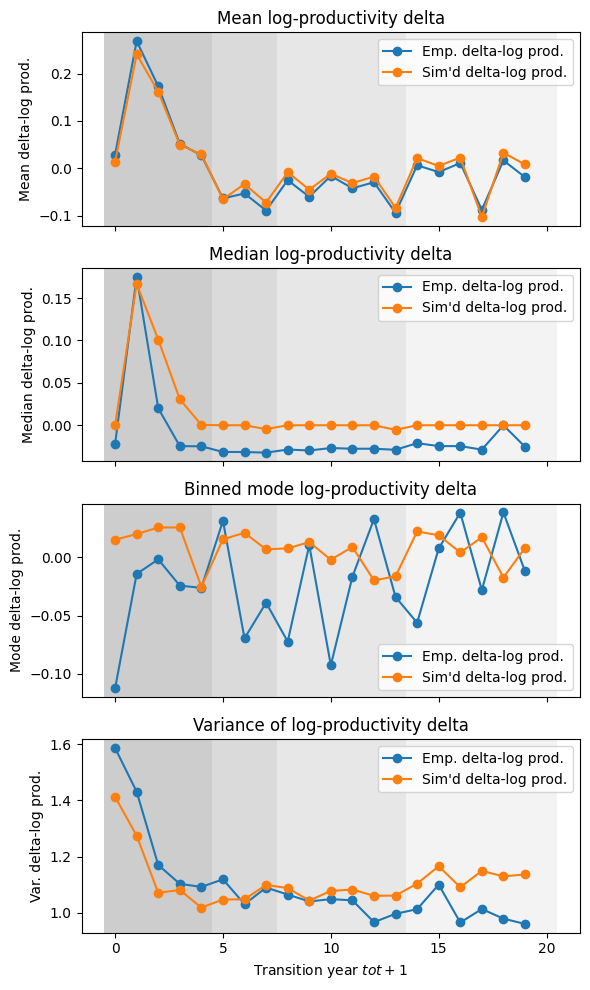

In [24]:
# Cell 13C: plot yearwise log-delta moments

fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)


axes[0].plot(emp_delta_stats["year"],emp_delta_stats["mean_log_delta"],marker="o", label="Emp. delta-log prod.", zorder=3)
axes[0].plot(sim_delta_stats["year"],sim_delta_stats["mean_log_delta"],marker="o",label="Sim'd delta-log prod.", zorder=3)
axes[0].set_title("Mean log-productivity delta")
axes[0].set_ylabel("Mean delta-log prod.")
axes[0].legend()

axes[1].plot(emp_delta_stats["year"],emp_delta_stats["median_log_delta"],marker="o",label="Emp. delta-log prod.",zorder=3)
axes[1].plot(sim_delta_stats["year"],sim_delta_stats["median_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[1].set_title("Median log-productivity delta")
axes[1].set_ylabel("Median delta-log prod.")
axes[1].legend()

axes[2].plot(emp_delta_stats["year"],emp_delta_stats["mode_log_delta"],marker="o",label="Emp. delta-log prod.",zorder=3)
axes[2].plot(sim_delta_stats["year"],sim_delta_stats["mode_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[2].set_title("Binned mode log-productivity delta")
axes[2].set_ylabel("Mode delta-log prod.")
axes[2].legend()

axes[3].plot(emp_delta_stats["year"],emp_delta_stats["var_log_delta"],marker="o",label="Emp. delta-log prod.", zorder=3)
axes[3].plot(sim_delta_stats["year"],sim_delta_stats["var_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[3].set_title("Variance of log-productivity delta")
axes[3].set_xlabel("Transition year $t \to t+1$")
axes[3].set_ylabel("Var. delta-log prod.")
axes[3].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_logDeltaMoments.png",dpi=300,bbox_inches="tight")
plt.show()


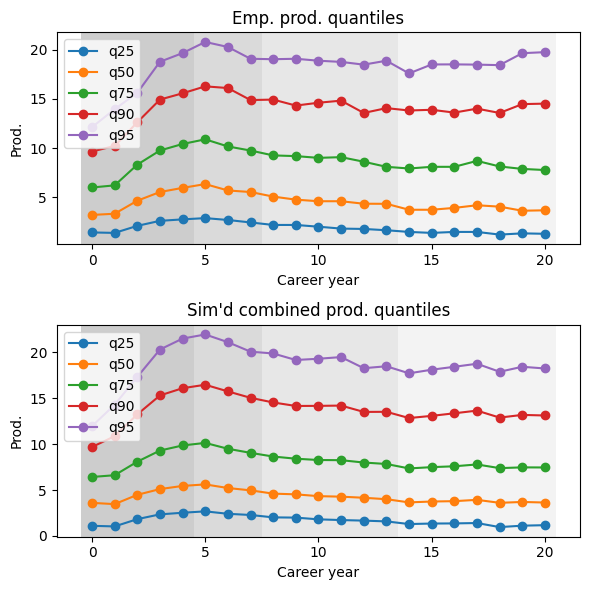

In [25]:
# Cell 14: yearwise quantile distrib dx

qcols = ["q25_prod", "q50_prod", "q75_prod", "q90_prod", "q95_prod"]

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )
for qcol in qcols:
    axes[0].plot(
        emp_year_stats["year"],
        emp_year_stats[qcol],
        marker="o",
        label=qcol.replace("_prod", ""), zorder = 3
    )

axes[0].set_title("Emp. prod. quantiles")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Prod.")
axes[0].legend()

for qcol in qcols:
    axes[1].plot(
        sim_year_stats["year"],
        sim_year_stats[qcol],
        marker="o",
        label=qcol.replace("_prod", ""), zorder = 3
    )

axes[1].set_title("Sim'd combined prod. quantiles")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_quantiles.png", dpi=300, bbox_inches="tight")
plt.show()

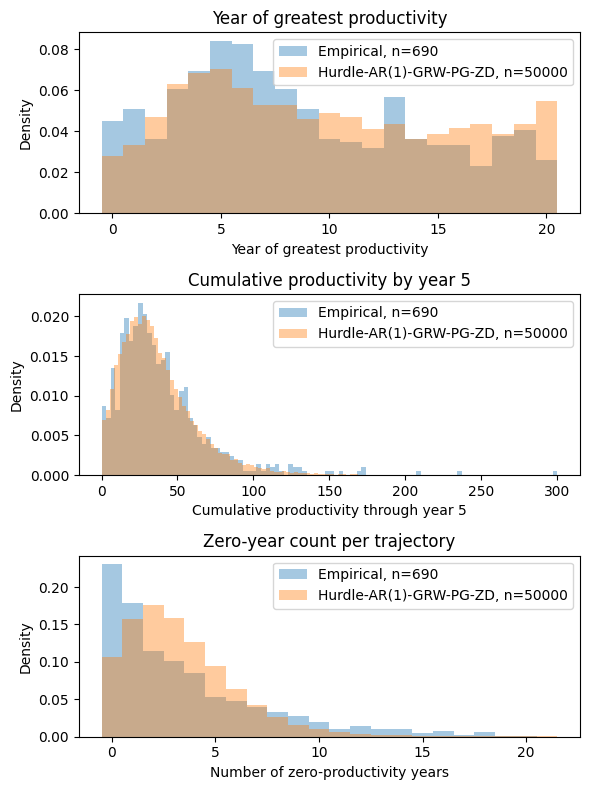

Full empirical trajectories: 690
Simulated trajectories: 50000
KS year of greatest productivity: KstestResult(statistic=np.float64(0.08780492753623181), pvalue=np.float64(5.114915016728048e-05), statistic_location=np.int64(9), statistic_sign=np.int8(1))
KS cumulative productivity by year 5: KstestResult(statistic=np.float64(0.028630434782608627), pvalue=np.float64(0.6214123672979468), statistic_location=np.float64(52.61054568170949), statistic_sign=np.int8(-1))
KS zero-year count: KstestResult(statistic=np.float64(0.14459565217391307), pvalue=np.float64(6.88104814693488e-13), statistic_location=np.int64(1), statistic_sign=np.int8(1))


In [26]:
# Cell 15: dx, norm'd

emp_panel = (working_df[working_df["CareerAge"].between(0, Y)].pivot_table(index="dblp_id", columns="CareerAge", values="pubs_adj"))

emp_panel_full = emp_panel.dropna()

emp_year_max = emp_panel_full.idxmax(axis=1)
emp_cum_y5 = emp_panel_full.loc[:, 0:5].sum(axis=1)
emp_zero_count = (emp_panel_full == 0).sum(axis=1)

sim_year_max = np.argmax(trajs_combined, axis=0)
sim_cum_y5 = trajs_combined[0:6, :].sum(axis=0)
sim_zero_count = (trajs_combined == 0).sum(axis=0)

ks_year_max = stats.ks_2samp(emp_year_max, sim_year_max)
ks_cum_y5 = stats.ks_2samp(emp_cum_y5, sim_cum_y5)
ks_zero_count = stats.ks_2samp(emp_zero_count, sim_zero_count)

fig, axes = plt.subplots(3, 1, figsize=(6, 8))

axes[0].hist(
    emp_year_max,
    bins=np.arange(-0.5, Y + 1.5, 1),
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_year_max)}")

axes[0].hist(
    sim_year_max,
    bins=np.arange(-0.5, Y + 1.5, 1),
    alpha=0.4,
    density=True,
    label=f"{MODEL_NAME}, n={len(sim_year_max)}")

axes[0].set_xlabel("Year of greatest productivity")
axes[0].set_ylabel("Density")
axes[0].set_title("Year of greatest productivity")
axes[0].legend()

axes[1].hist(
    emp_cum_y5,
    bins=100,
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_cum_y5)}")

axes[1].hist(
    sim_cum_y5,
    bins=100,
    alpha=0.4,
    density=True,
    label=f"{MODEL_NAME}, n={len(sim_cum_y5)}")

axes[1].set_xlabel("Cumulative productivity through year 5")
axes[1].set_ylabel("Density")
axes[1].set_title("Cumulative productivity by year 5")
axes[1].legend()

axes[2].hist(
    emp_zero_count,
    bins=np.arange(-0.5, Y + 2.5, 1),
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_zero_count)}")

axes[2].hist(
    sim_zero_count,
    bins=np.arange(-0.5, Y + 2.5, 1),
    alpha=0.4,
    density=True,
    label=f"{MODEL_NAME}, n={len(sim_zero_count)}")

axes[2].set_xlabel("Number of zero-productivity years")
axes[2].set_ylabel("Density")
axes[2].set_title("Zero-year count per trajectory")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_distribs.png", dpi=300, bbox_inches="tight")
plt.show()

print("Full empirical trajectories:", len(emp_panel_full))
print("Simulated trajectories:", trajs_combined.shape[1])
print("KS year of greatest productivity:", ks_year_max)
print("KS cumulative productivity by year 5:", ks_cum_y5)
print("KS zero-year count:", ks_zero_count)


In [27]:
# Cell 18: numerical summary

summary = {
    "empirical_mean_y0": emp_mean.loc[0],
    "empirical_mean_y5": emp_mean.loc[5],
    "empirical_mean_y10": emp_mean.loc[10],
    "empirical_mean_y20": emp_mean.loc[20],
    "simulated_mean_y0": sim_mean[0],
    "simulated_mean_y5": sim_mean[5],
    "simulated_mean_y10": sim_mean[10],
    "simulated_mean_y20": sim_mean[20],
    "empirical_median_y0": emp_median.loc[0],
    "empirical_median_y5": emp_median.loc[5],
    "empirical_median_y10": emp_median.loc[10],
    "empirical_median_y20": emp_median.loc[20],
    "simulated_median_y0": sim_median[0],
    "simulated_median_y5": sim_median[5],
    "simulated_median_y10": sim_median[10],
    "simulated_median_y20": sim_median[20],
    "empirical_frac_zero_y0": emp_frac_zero.loc[0],
    "empirical_frac_zero_y5": emp_frac_zero.loc[5],
    "empirical_frac_zero_y10": emp_frac_zero.loc[10],
    "empirical_frac_zero_y20": emp_frac_zero.loc[20],
    "simulated_frac_zero_y0": sim_frac_zero[0],
    "simulated_frac_zero_y5": sim_frac_zero[5],
    "simulated_frac_zero_y10": sim_frac_zero[10],
    "simulated_frac_zero_y20": sim_frac_zero[20],
    "dropout_gamma_log1p_q": fitted_gamma,
    "dropout_nll": opt.fun,
    "restart_rho_zero_run_excess": fitted_restart_rho,
    "restart_duration_nll": restart_opt.fun,
    "p_init_active": p_init_active,
    "gamma_q0_shape": gamma_q0_shape,
    "gamma_q0_scale": gamma_q0_scale,
    "gamma_q0_rate": gamma_q0_rate,
    "alpha_restart": alpha_restart,
    "lambda_restart": lambda_restart,
    "restart_n": len(restart_q_empirical),
    "simulated_y20_q95": np.quantile(trajs_combined[20], 0.95),
    "simulated_y20_q99": np.quantile(trajs_combined[20], 0.99),
    "simulated_y20_max": np.max(trajs_combined[20]),
    "ks_year_max_stat": ks_year_max.statistic,
    "ks_year_max_p": ks_year_max.pvalue,
    "ks_cum_y5_stat": ks_cum_y5.statistic,
    "ks_cum_y5_p": ks_cum_y5.pvalue,
    "ks_zero_count_stat": ks_zero_count.statistic,
    "ks_zero_count_p": ks_zero_count.pvalue,}

summary_df = pd.DataFrame([summary])

print("Yearwise unconditioned transition summary, retained for comparison")
display(year_transition_summary.round(3))

print("Parametric monotone dropout model summary")
display(dropout_param_summary.round(4))

print("Parametric zero-run-duration restart model summary")
display(restart_param_summary.round(4))

print("Yearwise positive-only AR(1) params")
display(year_ar1_params)

print("Gamma initial / exponential restart params")
display(pd.DataFrame([{
    "gamma_q0_shape": gamma_q0_shape,
    "gamma_q0_scale": gamma_q0_scale,
    "gamma_q0_rate": gamma_q0_rate,
    "alpha_restart": alpha_restart,
    "lambda_restart": lambda_restart,
    "restart_n": len(restart_q_empirical),
    "p_init_active": p_init_active,
    "dropout_gamma_log1p_q": fitted_gamma,
    "restart_rho_zero_run_excess": fitted_restart_rho,
}]))

print("Summary")
display(summary_df)


Yearwise unconditioned transition summary, retained for comparison


,year,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0,2067,0.380,0.620,0.164,0.836
1,1,2143,0.316,0.684,0.109,0.891
2,2,2202,0.362,0.638,0.075,0.925
3,3,2247,0.380,0.620,0.082,0.918
4,4,2259,0.408,0.592,0.076,0.924
5,5,2200,0.442,0.558,0.077,0.923
6,6,2142,0.408,0.592,0.078,0.922
7,7,2059,0.407,0.593,0.095,0.905
8,8,1985,0.407,0.593,0.086,0.914
9,9,1895,0.483,0.517,0.094,0.906


Parametric monotone dropout model summary


,year,n_active_transitions,observed_dropout_rate,dropout_intercept,dropout_gamma_log1p_q,pred_drop_q25,pred_drop_q50,pred_drop_q75,pred_drop_q95
0,0,1633,0.1641,0.2482,1.1886,0.1876,0.1156,0.0688,0.0338
1,1,1710,0.1088,-0.2217,1.1886,0.1261,0.0755,0.0441,0.0214
2,2,1879,0.0750,-0.4681,1.1886,0.1014,0.0600,0.0348,0.0168
3,3,1989,0.0825,-0.2655,1.1886,0.1214,0.0725,0.0423,0.0205
4,4,1997,0.0756,-0.2912,1.1886,0.1187,0.0708,0.0413,0.0200
5,5,1942,0.0772,-0.2168,1.1886,0.1267,0.0758,0.0443,0.0215
6,6,1880,0.0782,-0.2556,1.1886,0.1224,0.0732,0.0427,0.0207
7,7,1806,0.0952,-0.0814,1.1886,0.1424,0.0859,0.0504,0.0245
8,8,1710,0.0860,-0.2522,1.1886,0.1228,0.0734,0.0429,0.0208
9,9,1636,0.0935,-0.1788,1.1886,0.1309,0.0786,0.0460,0.0223


Parametric zero-run-duration restart model summary


...

,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,0,1365,0.819365,0.487050,0.659691,0.435192,1.597357,0.570532,-2.931314e-16,0.659691
1,1,1524,1.012746,0.480930,0.632968,0.400649,1.951079,0.521199,-7.960969e-16,0.632968
2,2,1738,0.883562,0.565076,0.635208,0.403490,2.031531,0.592766,-4.497106e-17,0.635208
3,3,1825,0.864084,0.564572,0.626882,0.392981,1.984447,0.576845,9.616661e-16,0.626882
4,4,1846,0.861894,0.565928,0.611380,0.373786,1.985604,0.549907,-5.032690e-16,0.611380
5,5,1792,0.762904,0.571968,0.635388,0.403717,1.782353,0.600009,7.335402e-17,0.635388
6,6,1733,0.688805,0.599914,0.628445,0.394943,1.721643,0.616999,-5.289095e-16,0.628445
7,7,1634,0.672751,0.599344,0.651036,0.423848,1.679121,0.661448,-8.283867e-16,0.651036
8,8,1563,0.695445,0.591099,0.641449,0.411457,1.700767,0.632424,2.312787e-16,0.641449
9,9,1483,0.641599,0.618118,0.652205,0.425371,1.680096,0.688380,4.012674e-17,0.652205


Gamma initial / exponential restart params


,gamma_q0_shape,gamma_q0_scale,gamma_q0_rate,alpha_restart,lambda_restart,restart_n,p_init_active,dropout_gamma_log1p_q,restart_rho_zero_run_excess
0,2.15167,2.531674,0.394996,4.299784,0.23257,3061,0.790237,1.188553,0.299223


Summary


,empirical_mean_y0,empirical_mean_y5,empirical_mean_y10,empirical_mean_y20,simulated_mean_y0,simulated_mean_y5,simulated_mean_y10,simulated_mean_y20,empirical_median_y0,empirical_median_y5,...,restart_n,simulated_y20_q95,simulated_y20_q99,simulated_y20_max,ks_year_max_stat,ks_year_max_p,ks_cum_y5_stat,ks_cum_y5_p,ks_zero_count_stat,ks_zero_count_p
0,4.304679,7.729319,6.428626,5.797863,4.319176,7.577882,6.280401,5.60327,3.225469,6.352937,...,3061,18.248182,33.250454,141.872849,0.087805,0.000051,0.02863,0.621412,0.144596,6.881048e-13


In [28]:
# Cell 19: save outputs

year_transition_summary.to_csv(RESULTS / f"{MODEL_TAG}_yearTransitionSummary.csv", index=False)
stage_transition_summary.to_csv(RESULTS / f"{MODEL_TAG}_stageTransitionSummary.csv", index=False)
dropout_param_summary.to_csv(RESULTS / f"{MODEL_TAG}_paramDropoutSummary.csv", index=False)
restart_param_summary.to_csv(RESULTS / f"{MODEL_TAG}_paramRestartDurationSummary.csv", index=False)
year_ar1_params.to_csv(RESULTS / f"{MODEL_TAG}_posYearLog.csv", index=False)
global_ar1_params.to_csv(RESULTS / f"{MODEL_TAG}_pos_globalLog.csv", index=False)
emp_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_empYearStats.csv", index=False)
sim_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_simYearStats.csv", index=False)
emp_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_empLogDeltaStats.csv", index=False)
sim_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_simLogDeltaStats.csv", index=False)
summary_df.to_csv(RESULTS / f"{MODEL_TAG}_Summary.csv", index=False)

def matrix_dict_to_frame(matrix_dict, level_name):
    rows = []
    for key, mat in matrix_dict.items():
        rows.append({
            level_name: key,
            "P_nothing_to_nothing": mat.loc[0, 0],
            "P_nothing_to_something": mat.loc[0, 1],
            "P_something_to_nothing": mat.loc[1, 0],
            "P_something_to_something": mat.loc[1, 1],})
    return pd.DataFrame(rows)

matrix_dict_to_frame(year_P, "year").to_csv(RESULTS / f"{MODEL_TAG}_yearPMatrices_comparison.csv", index=False)
matrix_dict_to_frame(stage_P, "stage").to_csv(RESULTS / f"{MODEL_TAG}_stagePMatrices_comparison.csv", index=False)

pd.DataFrame({
    "year": np.arange(Y),
    "dropout_intercept": fitted_intercepts,
    "dropout_gamma_log1p_q": fitted_gamma,
    "restart_intercept": fitted_restart_intercepts,
    "restart_rho_zero_run_excess": fitted_restart_rho,
    "pred_restart_run1": [predict_restart_prob(1, year) for year in range(Y)],
    "pred_restart_run2": [predict_restart_prob(2, year) for year in range(Y)],
    "pred_restart_run3": [predict_restart_prob(3, year) for year in range(Y)],
    "pred_restart_run5": [predict_restart_prob(5, year) for year in range(Y)],
}).to_csv(RESULTS / f"{MODEL_TAG}_paramHurdleParams.csv", index=False)

with open(RESULTS / f"{MODEL_TAG}_report.txt", "w") as f:
    f.write("parametric productivity-conditioned hurdle with gamma initialization and zero-run duration dependence, yearwise AR(1) report\n")
    f.write("\n")
    f.write("Model\n")
    f.write("\n")
    f.write("B_0 ~ Bernoulli(p_init_active).\n")
    f.write("Q_0 ~ Gamma(k_0, theta_0) if B_0=1; otherwise Q_0=0.\n")
    f.write("If B_t=0, Pr(B_{t+1}=1 | L_t) = logistic(c_t - rho (L_t - 1)), where L_t is current zero-run length.\n")
    f.write("If B_t=1, Pr(B_{t+1}=0 | Q_t) = logistic(a_t - gamma log(1 + Q_t)), gamma >= 0.\n")
    f.write("Q_{t+1} = 0 if B_{t+1}=0.\n")
    f.write("Q_{t+1} ~ Exponential(lambda_R) if B_t=0 and B_{t+1}=1.\n")
    f.write("log(Q_{t+1}) = intercept_t + beta_t log(Q_t) + error_t if B_t=1 and B_{t+1}=1.\n")
    f.write("error_t ~ Normal(0, sigma_t^2).\n")
    f.write("\n")
    f.write(f"EPS = {EPS}\n")
    f.write(f"N = {N}\n")
    f.write(f"Y = {Y}\n")
    f.write(f"p_init_active = {p_init_active}\n")
    f.write(f"gamma_q0_shape = {gamma_q0_shape}\n")
    f.write(f"gamma_q0_scale = {gamma_q0_scale}\n")
    f.write(f"gamma_q0_rate = {gamma_q0_rate}\n")
    f.write(f"alpha_restart = {alpha_restart}\n")
    f.write(f"lambda_restart = {lambda_restart}\n")
    f.write(f"dropout_gamma_log1p_q = {fitted_gamma}\n")
    f.write(f"dropout_nll = {opt.fun}\n")
    f.write(f"restart_rho_zero_run_excess = {fitted_restart_rho}\n")
    f.write(f"restart_duration_nll = {restart_opt.fun}\n")
    f.write("\n")
    f.write("Parametric dropout summary\n")
    f.write("\n")
    f.write(dropout_param_summary.to_string(index=False))
    f.write("\n\nParametric restart-duration summary\n")
    f.write("\n")
    f.write(restart_param_summary.to_string(index=False))
    f.write("\n\nYearwise binary transition summary, retained for comparison\n")
    f.write("\n")
    f.write(year_transition_summary.to_string(index=False))
    f.write("\n\nYearwise positive-only AR(1) parameters\n")
    f.write("\n")
    f.write(year_ar1_params.to_string(index=False))
    f.write("\n\nGlobal positive-only AR(1) parameters\n")
    f.write("\n")
    f.write(global_ar1_params.to_string(index=False))
    f.write("\n\nsummary\n")
    f.write("-------\n")
    f.write(summary_df.to_string(index=False))


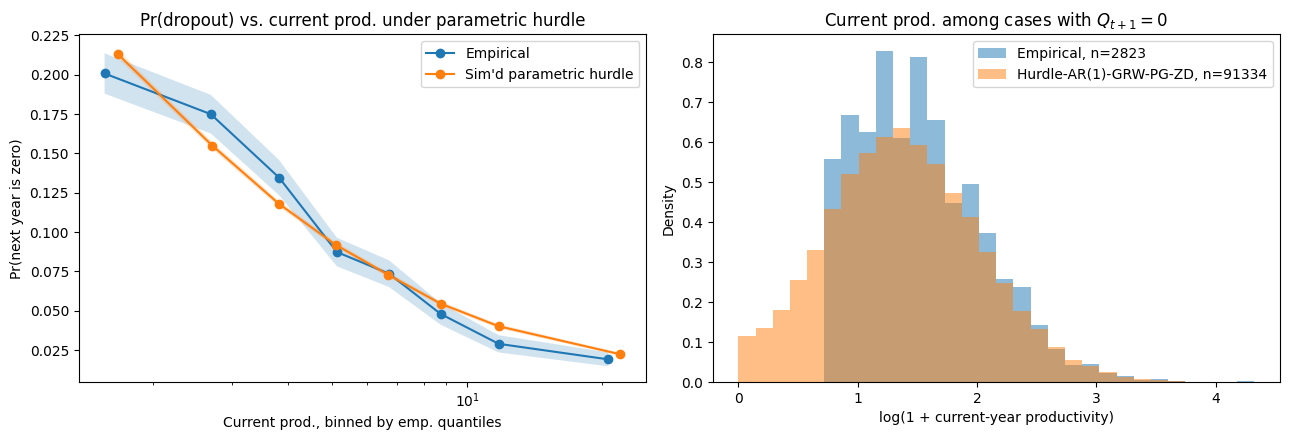

Empirical dropout by current productivity bin:


,prod_bin,n,dropout_rate,mean_q_t,median_q_t,source,bin_mid,se,lower,upper
0,"(1.0890000000000002, 2.181]",3760,0.200798,1.558408,1.502068,Empirical,1.558408,0.006533,0.187993,0.213603
1,"(2.181, 3.229]",3687,0.174939,2.687266,2.644809,Empirical,2.687266,0.006257,0.162676,0.187202
2,"(3.229, 4.419]",3575,0.134545,3.815607,3.811037,Empirical,3.815607,0.005707,0.123359,0.145731
3,"(4.419, 5.829]",3700,0.087297,5.131218,5.084822,Empirical,5.131218,0.004640,0.078202,0.096393
4,"(5.829, 7.622]",3631,0.073533,6.704440,6.691238,Empirical,6.704440,0.004332,0.065044,0.082023
5,"(7.622, 10.037]",3711,0.047966,8.732543,8.706188,Empirical,8.732543,0.003508,0.041090,0.054841
6,"(10.037, 14.001]",3592,0.028953,11.763405,11.657458,Empirical,11.763405,0.002798,0.023470,0.034437
7,"(14.001, 80.687]",3666,0.019094,20.622869,18.392702,Empirical,20.622869,0.002260,0.014664,0.023525


Simulated dropout by current productivity bin:


,prod_bin,n,dropout_rate,mean_q_t,median_q_t,source,bin_mid,se,lower,upper
0,"(1.0890000000000002, 2.181]",92682,0.212997,1.669788,1.684835,Simulated,1.669788,0.001345,0.210361,0.215633
1,"(2.181, 3.229]",105042,0.155005,2.706968,2.707861,Simulated,2.706968,0.001117,0.152816,0.157193
2,"(3.229, 4.419]",110918,0.117961,3.811178,3.804709,Simulated,3.811178,0.000969,0.116063,0.119859
3,"(4.419, 5.829]",109014,0.091915,5.096594,5.082480,Simulated,5.096594,0.000875,0.090200,0.093630
4,"(5.829, 7.622]",104328,0.072847,6.675860,6.649122,Simulated,6.675860,0.000805,0.071270,0.074424
5,"(7.622, 10.037]",93364,0.054507,8.731925,8.683285,Simulated,8.731925,0.000743,0.053051,0.055963
6,"(10.037, 14.001]",84571,0.040096,11.772055,11.651663,Simulated,11.772055,0.000675,0.038774,0.041419
7,"(14.001, 80.687]",96697,0.022296,21.965218,18.930461,Simulated,21.965218,0.000475,0.021366,0.023227


In [29]:
# conditioned dropout 

emp_dx = working_df_fit.loc[
    working_df_fit["pubs_adj"].notna() &
    working_df_fit["pubs_adj_next"].notna(),
    ["CareerAge", "pubs_adj", "pubs_adj_next"]
].copy()

emp_dx = emp_dx.loc[emp_dx["pubs_adj"] > 0].copy()
emp_dx["drops_to_zero"] = (emp_dx["pubs_adj_next"] == 0).astype(int)


sim_dx = pd.DataFrame({
    "CareerAge": np.repeat(np.arange(Y), trajs_combined.shape[1]),
    "pubs_adj": trajs_combined[:-1, :].ravel(),
    "pubs_adj_next": trajs_combined[1:, :].ravel()})

sim_dx = sim_dx.loc[sim_dx["pubs_adj"] > 0].copy()
sim_dx["drops_to_zero"] = (sim_dx["pubs_adj_next"] == 0).astype(int)

n_bins = 8

bin_edges = np.quantile(emp_dx["pubs_adj"], np.linspace(0, 1, n_bins + 1))

bin_edges = np.unique(bin_edges)

if len(bin_edges) < 3:
    raise ValueError("Not enough unique emp bin edges")

emp_dx["prod_bin"] = pd.cut(
    emp_dx["pubs_adj"],
    bins=bin_edges,
    include_lowest=True,
    duplicates="drop"
)

sim_dx["prod_bin"] = pd.cut(
    sim_dx["pubs_adj"],
    bins=bin_edges,
    include_lowest=True,
    duplicates="drop"
)

def summarize_dropout_by_bin(df, label):
    out = (
        df.groupby("prod_bin", observed=False)
        .agg(
            n=("drops_to_zero", "size"),
            dropout_rate=("drops_to_zero", "mean"),
            mean_q_t=("pubs_adj", "mean"),
            median_q_t=("pubs_adj", "median")
        )
        .reset_index()
    )

    out["source"] = label
    out["bin_mid"] = out["mean_q_t"]

    out["se"] = np.sqrt(out["dropout_rate"] * (1 - out["dropout_rate"]) / out["n"])
    out["lower"] = np.clip(out["dropout_rate"] - 1.96 * out["se"], 0, 1)
    out["upper"] = np.clip(out["dropout_rate"] + 1.96 * out["se"], 0, 1)

    return out

emp_bin_summary = summarize_dropout_by_bin(emp_dx, "Empirical")
sim_bin_summary = summarize_dropout_by_bin(sim_dx, "Simulated")

dropout_bin_summary = pd.concat([emp_bin_summary, sim_bin_summary], ignore_index=True)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(
    emp_bin_summary["bin_mid"],
    emp_bin_summary["dropout_rate"],
    marker="o",
    label="Empirical"
)

axes[0].fill_between(
    emp_bin_summary["bin_mid"],
    emp_bin_summary["lower"],
    emp_bin_summary["upper"],
    alpha=0.20
)

axes[0].plot(
    sim_bin_summary["bin_mid"],
    sim_bin_summary["dropout_rate"],
    marker="o",
    label="Sim'd parametric hurdle"
)

axes[0].fill_between(
    sim_bin_summary["bin_mid"],
    sim_bin_summary["lower"],
    sim_bin_summary["upper"],
    alpha=0.20
)

axes[0].set_xlabel("Current prod., binned by emp. quantiles")
axes[0].set_ylabel("Pr(next year is zero)")
axes[0].set_title("Pr(dropout) vs. current prod. under parametric hurdle")
axes[0].legend()

axes[0].set_xscale("log")

emp_prezero = emp_dx.loc[emp_dx["drops_to_zero"] == 1, "pubs_adj"]
sim_prezero = sim_dx.loc[sim_dx["drops_to_zero"] == 1, "pubs_adj"]

hist_bins = np.histogram_bin_edges(
    np.log1p(pd.concat([emp_prezero, sim_prezero])),
    bins=30
)

axes[1].hist(
    np.log1p(emp_prezero),
    bins=hist_bins,
    density=True,
    alpha=0.5,
    label=f"Empirical, n={len(emp_prezero)}"
)

axes[1].hist(
    np.log1p(sim_prezero),
    bins=hist_bins,
    density=True,
    alpha=0.5,
    label=f"{MODEL_NAME}, n={len(sim_prezero)}"
)

axes[1].set_xlabel("log(1 + current-year productivity)")
axes[1].set_ylabel("Density")
axes[1].set_title(r"Current prod. among cases with $Q_{t+1}=0$")
axes[1].legend()

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES / f"{MODEL_TAG}_paramCondProdDropout.png",
    dpi=300,
    bbox_inches="tight"
)

dropout_bin_summary.to_csv(
    RESULTS / f"{MODEL_TAG}_paramCondProdDropoutSummary.csv",
    index=False
)

print("Empirical dropout by current productivity bin:")
display(emp_bin_summary)

print("Simulated dropout by current productivity bin:")
display(sim_bin_summary)

In [30]:
OUT = PROJ_ROOT / "data" / 'trajectory_correlation_data'

TRJ =  trajs_combined      

TRJ = np.asarray(TRJ)
if TRJ.shape[0] != 21 and TRJ.shape[1] == 21:
    TRJ = TRJ.T

assert TRJ.shape[0] == 21, f"expected 21 years, got {TRJ.shape}"

save_path = OUT / f"{MODEL_TAG}_trajs.npy"
np.save(save_path, TRJ)


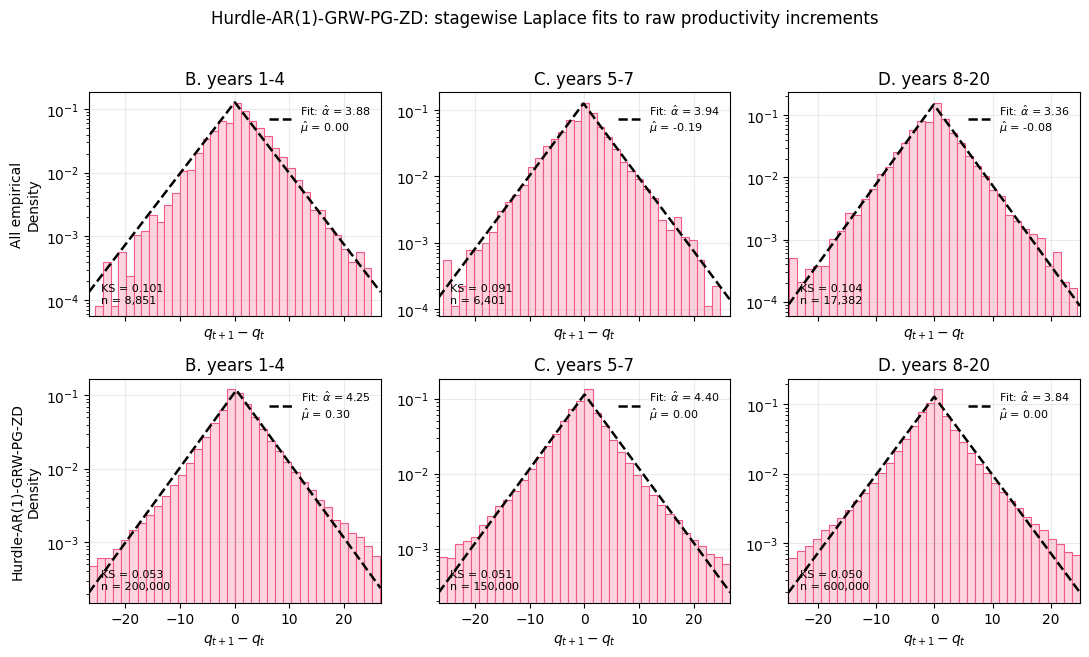

,model,source,stage,n,mu_hat,alpha_hat,ks_stat,mean,sd,q01,q50,q99
0,All empirical,empirical,B. years 1-4,8851,0.000000,3.879470,0.101040,0.756686,5.414004,-13.371327,0.000000,15.428888
1,All empirical,empirical,C. years 5-7,6401,-0.190708,3.937165,0.090950,-0.429310,5.622345,-15.275857,-0.190708,15.502144
2,All empirical,empirical,D. years 8-20,17382,-0.079308,3.363053,0.104041,-0.220967,4.886889,-13.966737,-0.079308,13.732907
3,Hurdle-AR(1)-GRW-PG-ZD,simulated,B. years 1-4,200000,0.298182,4.245252,0.052960,0.717875,6.793751,-18.084605,0.298182,21.457317
4,Hurdle-AR(1)-GRW-PG-ZD,simulated,C. years 5-7,150000,0.000000,4.397634,0.051339,-0.338678,7.212498,-21.437286,0.000000,20.479475
5,Hurdle-AR(1)-GRW-PG-ZD,simulated,D. years 8-20,600000,0.000000,3.844933,0.050325,-0.079881,6.647240,-19.368747,0.000000,19.327258


In [31]:
# cell 17: laplace

stage_years = {
    "B. years 1-4": np.arange(1, 5),
    "C. years 5-7": np.arange(5, 8),
    "D. years 8-20": np.arange(8, Y)}

def laplace_fit(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    mu = np.median(x)
    alpha = np.mean(np.abs(x - mu))
    ks = stats.kstest(x, "laplace", args=(mu, alpha)).statistic
    return mu, alpha, ks, len(x)

def laplace_pdf(x, mu, alpha):
    return (1 / (2 * alpha)) * np.exp(-np.abs(x - mu) / alpha)

def sim_stage_dx(trj, yrs):
    dx = trj[1:, :] - trj[:-1, :]
    return dx[yrs, :].ravel()

def emp_stage_dx(working_df, yrs):
    emp_dx = working_df.sort_values(["dblp_id", "CareerAge"]).copy()
    emp_dx["pubs_adj_next"] = emp_dx.groupby("dblp_id")["pubs_adj"].shift(-1)
    emp_dx["CareerAge_next"] = emp_dx.groupby("dblp_id")["CareerAge"].shift(-1)
    emp_dx["raw_delta"] = emp_dx["pubs_adj_next"] - emp_dx["pubs_adj"]

    keep = emp_dx["CareerAge_next"].eq(emp_dx["CareerAge"] + 1)
    keep &= emp_dx["CareerAge"].isin(yrs)

    return emp_dx.loc[keep, "raw_delta"].dropna().to_numpy()

plot_sources = [(MODEL_NAME, "simulated", TRJ)]

plot_sources = [("All empirical", "empirical", None)] + plot_sources

laplace_rows = []

xlims = {}
for stage, yrs in stage_years.items():
    pooled = []
    pooled.append(emp_stage_dx(working_df, yrs))

    pooled.append(sim_stage_dx(TRJ, yrs))

    pooled = np.concatenate([x for x in pooled if len(x) > 0])
    lo, hi = np.quantile(pooled, [0.005, 0.995])
    lim = max(abs(lo), abs(hi), 1)
    xlims[stage] = (-lim, lim)

fig, axes = plt.subplots(len(plot_sources), 3, figsize=(11, 3.2 * len(plot_sources)), sharex="col", sharey=False)

if len(plot_sources) == 1:
    axes = np.array([axes])

for r, (source_name, source_type, trj) in enumerate(plot_sources):
    for c, (stage, yrs) in enumerate(stage_years.items()):
        ax = axes[r, c]

        if source_type == "empirical":
            x = emp_stage_dx(working_df, yrs)
        else:
            x = sim_stage_dx(trj, yrs)

        mu, alpha, ks, n = laplace_fit(x)
        lo, hi = xlims[stage]
        x_plot = x[(x >= lo) & (x <= hi)]

        ax.hist(x_plot,bins=36,density=True,color="#ffd4df",edgecolor="#f05a87",linewidth=0.8)

        xx = np.linspace(lo, hi, 600)
        ax.plot(xx,laplace_pdf(xx, mu, alpha),linestyle="--",color="black",linewidth=1.8,label=rf"Fit: $\hat\alpha$ = {alpha:.2f}" + "\n" + rf"$\hat\mu$ = {mu:.2f}")

        ax.set_yscale("log")
        ax.set_xlim(lo, hi)
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
        ax.set_title(stage)
        ax.set_xlabel(r"$q_{t+1} - q_t$")

        if c == 0:
            ax.set_ylabel(f"{source_name}\nDensity")

        ax.text(0.04,0.06,f"KS = {ks:.3f}\nn = {n:,}",transform=ax.transAxes,fontsize=8)

        laplace_rows.append({
            "model": source_name,
            "source": source_type,
            "stage": stage,
            "n": n,
            "mu_hat": mu,
            "alpha_hat": alpha,
            "ks_stat": ks,
            "mean": np.mean(x),
            "sd": np.std(x, ddof=0),
            "q01": np.quantile(x, 0.01),
            "q50": np.quantile(x, 0.50),
            "q99": np.quantile(x, 0.99)})

fig.suptitle(f"{MODEL_NAME}: stagewise Laplace fits to raw productivity increments", y=1.02)
fig.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_stageRawIncrementLaplace.png", dpi=300, bbox_inches="tight")
plt.show()

laplace_stage_summary = pd.DataFrame(laplace_rows)
laplace_stage_summary.to_csv(RESULTS / f"{MODEL_TAG}_stageRawIncrementLaplace.csv", index=False)
laplace_stage_summary

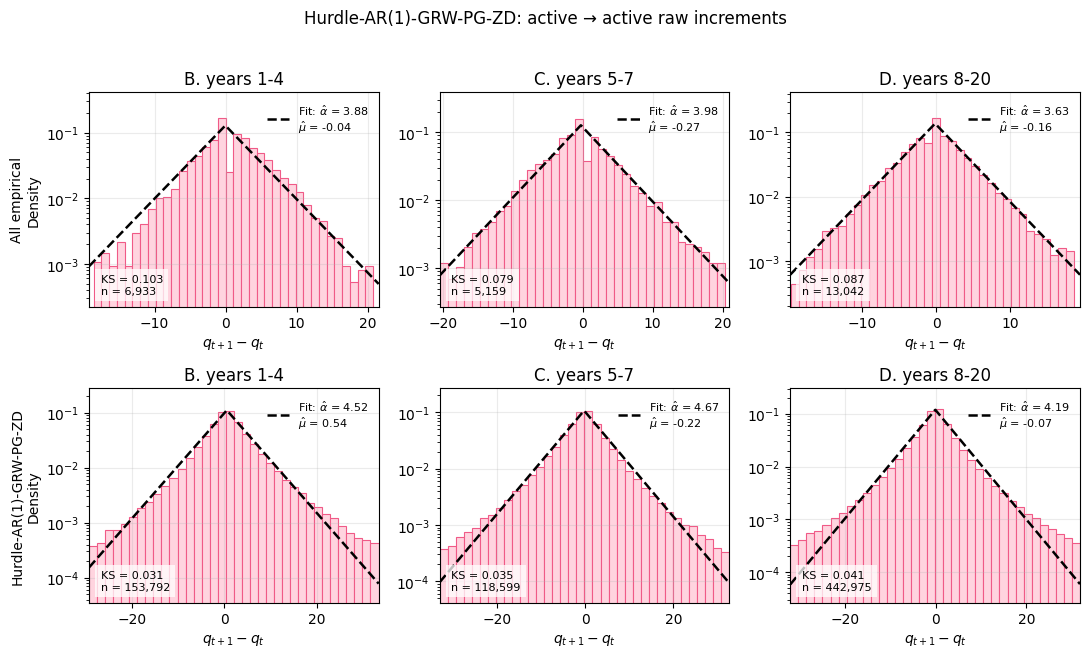

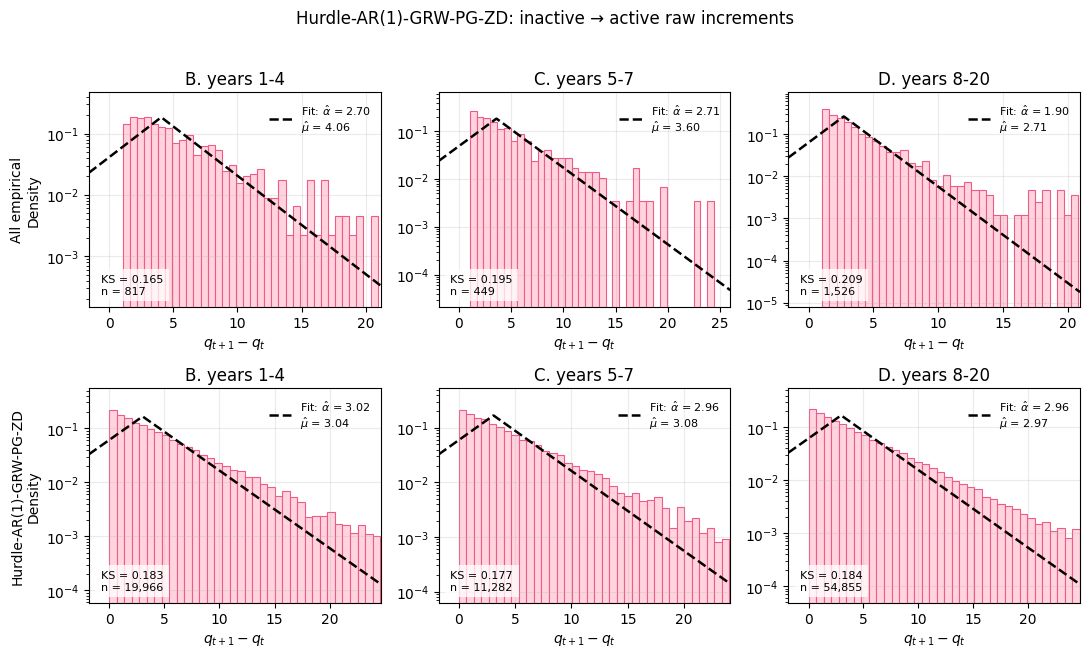

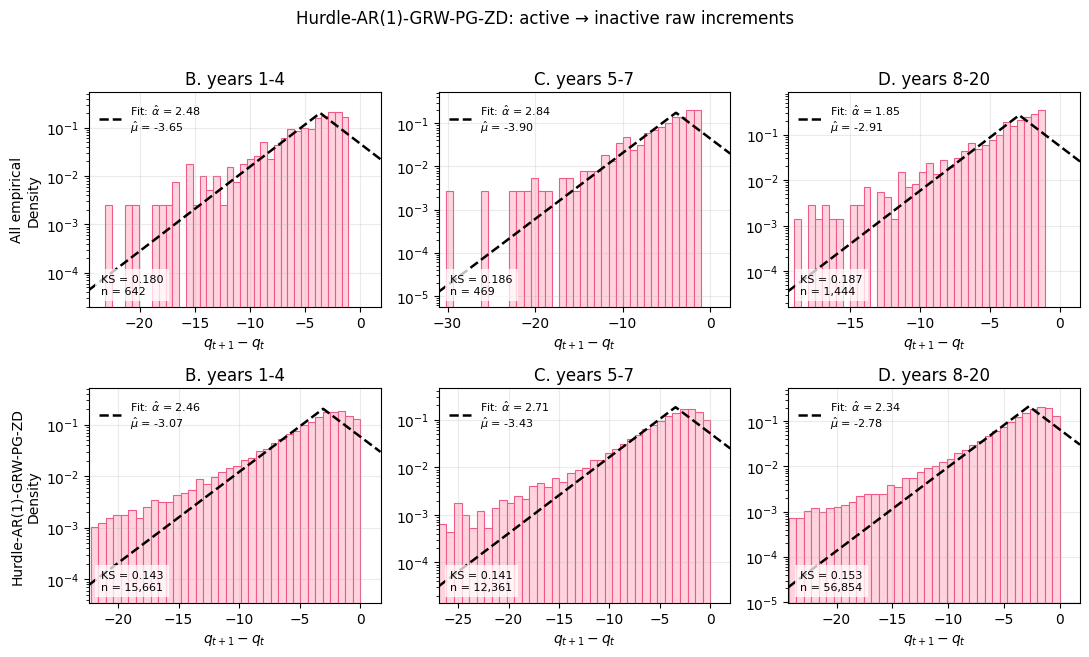

,source,stage,n,mu_hat,alpha_hat,ks_stat,mean,sd,q01,q50,q99,transition,transition_label,emp_q01,emp_q99,frac_outside_emp_1_99
1,Hurdle-AR(1)-GRW-PG-ZD,B. years 1-4,153792,0.536849,4.518276,0.030847,0.784267,7.216698,-19.391805,0.536849,23.060121,active_to_active,active → active,-12.944834,14.963747,0.056225
0,empirical,B. years 1-4,6933,-0.041633,3.880758,0.102863,0.801682,5.383436,-12.944834,-0.041633,14.963747,active_to_active,active → active,-12.944834,14.963747,NaN
3,Hurdle-AR(1)-GRW-PG-ZD,C. years 5-7,118599,-0.218829,4.670665,0.034870,-0.365728,7.630402,-22.698218,-0.218829,22.001398,active_to_active,active → active,-15.039792,15.342719,0.051240
2,empirical,C. years 5-7,5159,-0.274955,3.977838,0.079150,-0.483646,5.607226,-15.039792,-0.274955,15.342719,active_to_active,active → active,-15.039792,15.342719,NaN
5,Hurdle-AR(1)-GRW-PG-ZD,D. years 8-20,442975,-0.065159,4.188898,0.040693,-0.147349,7.184523,-21.128424,-0.065159,21.035946,active_to_active,active → active,-14.437689,14.204638,0.048538
4,empirical,D. years 8-20,13042,-0.161491,3.626348,0.087203,-0.304683,5.165246,-14.437689,-0.161491,14.204638,active_to_active,active → active,-14.437689,14.204638,NaN
13,Hurdle-AR(1)-GRW-PG-ZD,B. years 1-4,15661,-3.073231,2.456315,0.143135,-4.082876,3.733754,-17.935540,-3.073231,-0.077545,active_to_inactive,active → inactive,-18.394683,-1.231551,0.182236
12,empirical,B. years 1-4,642,-3.651052,2.483994,0.180132,-4.898404,3.845452,-18.394683,-3.651052,-1.231551,active_to_inactive,active → inactive,-18.394683,-1.231551,NaN
15,Hurdle-AR(1)-GRW-PG-ZD,C. years 5-7,12361,-3.432116,2.709781,0.140924,-4.549670,4.285726,-20.345727,-3.432116,-0.105308,active_to_inactive,active → inactive,-21.927045,-1.146671,0.138338
14,empirical,C. years 5-7,469,-3.902057,2.836703,0.185601,-5.185207,4.451195,-21.927045,-3.902057,-1.146671,active_to_inactive,active → inactive,-21.927045,-1.146671,NaN


In [32]:
# Cell 19B: transition-specific raw increment Laplace dx


ACTIVE_TOL = 0

transition_classes = {
    "active_to_active": "active → active",
    "inactive_to_active": "inactive → active",
    "active_to_inactive": "active → inactive",
    "inactive_to_inactive": "inactive → inactive"}

plot_transitions = [
    "active_to_active",
    "inactive_to_active",
    "active_to_inactive"]

def laplace_fit(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()

    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0

    mu = np.median(x)
    alpha = np.mean(np.abs(x - mu))

    if alpha <= 0 or not np.isfinite(alpha):
        return mu, alpha, np.nan, len(x)

    ks = stats.kstest(x, "laplace", args=(mu, alpha)).statistic
    return mu, alpha, ks, len(x)

def laplace_pdf(x, mu, alpha):
    return (1 / (2 * alpha)) * np.exp(-np.abs(x - mu) / alpha)

def transition_label(q0, q1):
    active0 = q0 > ACTIVE_TOL
    active1 = q1 > ACTIVE_TOL

    out = np.full(q0.shape, "inactive_to_inactive", dtype=object)
    out[active0 & active1] = "active_to_active"
    out[(~active0) & active1] = "inactive_to_active"
    out[active0 & (~active1)] = "active_to_inactive"

    return out

def sim_transition_dx(trj, yrs, transition):
    q0 = trj[:-1, :]
    q1 = trj[1:, :]
    dx = q1 - q0
    lab = transition_label(q0, q1)

    keep_year = np.isin(np.arange(q0.shape[0]), yrs)[:, None]
    keep = keep_year & (lab == transition)

    return dx[keep]

def emp_transition_frame(working_df):
    emp_dx = working_df.sort_values(["dblp_id", "CareerAge"]).copy()
    emp_dx["pubs_adj_next"] = emp_dx.groupby("dblp_id")["pubs_adj"].shift(-1)
    emp_dx["CareerAge_next"] = emp_dx.groupby("dblp_id")["CareerAge"].shift(-1)
    emp_dx["raw_delta"] = emp_dx["pubs_adj_next"] - emp_dx["pubs_adj"]

    keep = emp_dx["CareerAge_next"].eq(emp_dx["CareerAge"] + 1)
    emp_dx = emp_dx.loc[keep].copy()

    q0 = emp_dx["pubs_adj"].to_numpy()
    q1 = emp_dx["pubs_adj_next"].to_numpy()

    emp_dx["transition"] = transition_label(q0, q1)

    return emp_dx

def emp_transition_dx(emp_dx, yrs, transition):
    keep = emp_dx["CareerAge"].isin(yrs)
    keep &= emp_dx["transition"].eq(transition)

    return emp_dx.loc[keep, "raw_delta"].dropna().to_numpy()

def panel_xlim(x, q=0.995, pad=0.08):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()

    if len(x) == 0:
        return -1, 1

    lo, hi = np.quantile(x, [1 - q, q])
    lo = min(lo, 0)
    hi = max(hi, 0)

    span = max(hi - lo, 1)
    return lo - pad * span, hi + pad * span

def plot_dx_panel(ax, x, title, source_name):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    mu, alpha, ks, n = laplace_fit(x)
    lo, hi = panel_xlim(x)

    x_plot = x[(x >= lo) & (x <= hi)]

    if len(x_plot) > 0:
        counts, edges = np.histogram(x_plot, bins=36, density=True)
        widths = np.diff(edges)
        keep = counts > 0

        ax.bar(
            edges[:-1][keep],
            counts[keep],
            width=widths[keep],
            align="edge",
            color="#ffd4df",
            edgecolor="#f05a87",
            linewidth=0.8
        )

        y_pos = counts[counts > 0]
    else:
        y_pos = np.array([])

    xx = np.linspace(lo, hi, 600)

    if np.isfinite(alpha) and alpha > 0:
        yy = laplace_pdf(xx, mu, alpha)
        ax.plot(
            xx,
            yy,
            linestyle="--",
            color="black",
            linewidth=1.8,
            label=rf"Fit: $\hat\alpha$ = {alpha:.2f}" + "\n" + rf"$\hat\mu$ = {mu:.2f}"
        )

        y_pos = np.r_[y_pos, yy[np.isfinite(yy) & (yy > 0)]]

    if len(y_pos) > 0:
        ax.set_ylim(max(y_pos.min() * 0.45, 1e-6), y_pos.max() * 2.5)

    ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(r"$q_{t+1} - q_t$")

    ax.text(
        0.04,
        0.06,
        f"KS = {ks:.3f}\nn = {n:,}",
        transform=ax.transAxes,
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75)
    )

    return {
        "source": source_name,
        "stage": title,
        "n": n,
        "mu_hat": mu,
        "alpha_hat": alpha,
        "ks_stat": ks,
        "mean": np.mean(x) if len(x) else np.nan,
        "sd": np.std(x, ddof=0) if len(x) else np.nan,
        "q01": np.quantile(x, 0.01) if len(x) else np.nan,
        "q50": np.quantile(x, 0.50) if len(x) else np.nan,
        "q99": np.quantile(x, 0.99) if len(x) else np.nan}

emp_dx = emp_transition_frame(working_df)
transition_rows = []

for transition in plot_transitions:
    fig, axes = plt.subplots(2, 3, figsize=(11, 6.4))

    for c, (stage, yrs) in enumerate(stage_years.items()):
        x_emp = emp_transition_dx(emp_dx, yrs, transition)
        x_sim = sim_transition_dx(TRJ, yrs, transition)

        row = plot_dx_panel(axes[0, c], x_emp, stage, "empirical")
        row["transition"] = transition
        row["transition_label"] = transition_classes[transition]
        transition_rows.append(row)

        row = plot_dx_panel(axes[1, c], x_sim, stage, MODEL_NAME)
        row["transition"] = transition
        row["transition_label"] = transition_classes[transition]
        transition_rows.append(row)

        if c == 0:
            axes[0, c].set_ylabel("All empirical\nDensity")
            axes[1, c].set_ylabel(f"{MODEL_NAME}\nDensity")

    fig.suptitle(
        f"{MODEL_NAME}: {transition_classes[transition]} raw increments",
        y=1.02
    )

    fig.tight_layout()
    plt.savefig(
        FIGURES / f"{MODEL_TAG}_{transition}_rawIncrementLaplace.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

for transition in transition_classes:
    for stage, yrs in stage_years.items():
        x_emp = emp_transition_dx(emp_dx, yrs, transition)
        x_sim = sim_transition_dx(TRJ, yrs, transition)

        if transition == "inactive_to_inactive":
            for source_name, x in [("empirical", x_emp), (MODEL_NAME, x_sim)]:
                transition_rows.append({
                    "source": source_name,
                    "stage": stage,
                    "transition": transition,
                    "transition_label": transition_classes[transition],
                    "n": len(x),
                    "mu_hat": 0,
                    "alpha_hat": 0,
                    "ks_stat": np.nan,
                    "mean": 0,
                    "sd": 0,
                    "q01": 0,
                    "q50": 0,
                    "q99": 0
                })

transition_laplace_summary = pd.DataFrame(transition_rows)

emp_bounds = (
    transition_laplace_summary
    .query("source == 'empirical'")
    [["stage", "transition", "q01", "q99"]]
    .rename(columns={"q01": "emp_q01", "q99": "emp_q99"})
)

transition_laplace_summary = transition_laplace_summary.merge(
    emp_bounds,
    on=["stage", "transition"],
    how="left"
)

outside_emp = []

for _, row in transition_laplace_summary.iterrows():
    if row["source"] == "empirical":
        outside_emp.append(np.nan)
        continue

    yrs = stage_years[row["stage"]]
    x = sim_transition_dx(TRJ, yrs, row["transition"])

    if len(x) == 0 or not np.isfinite(row["emp_q01"]) or not np.isfinite(row["emp_q99"]):
        outside_emp.append(np.nan)
    else:
        outside_emp.append(((x < row["emp_q01"]) | (x > row["emp_q99"])).mean())

transition_laplace_summary["frac_outside_emp_1_99"] = outside_emp

transition_laplace_summary.to_csv(
    RESULTS / f"{MODEL_TAG}_transitionRawIncrementLaplace.csv",
    index=False
)

transition_laplace_summary.sort_values(["transition", "stage", "source"])

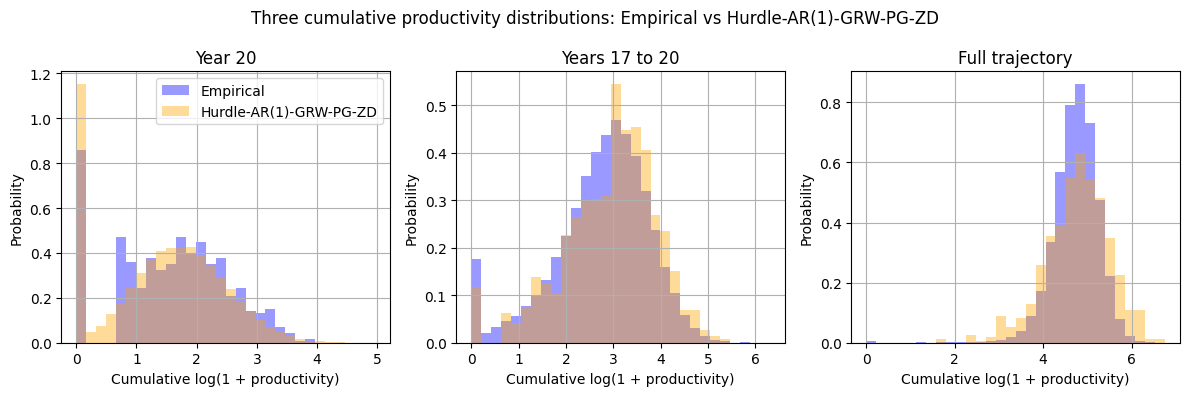

In [163]:
lastyear_sim = trajs_combined[20]
lastyear_emp = emp_panel_full[20]
hist_bins_lastyear = np.histogram_bin_edges((np.log1p(np.concat([[0],lastyear_sim, lastyear_emp]))),bins=30)

lastfour_sim = trajs_combined[-4:,:].sum(axis = 0)
lastfour_emp = emp_panel_full.iloc[:, -4:].sum(axis=1).to_numpy()
hist_bins_lastfour = np.histogram_bin_edges((np.log1p(np.concat([[0],lastfour_sim, lastfour_emp]))),bins=30)

cumsim = trajs_combined.sum(axis = 0)
cumemp = emp_panel_full.sum(axis=1).to_numpy()
hist_bins_cum = np.histogram_bin_edges((np.log1p(np.concat([[0],cumsim, cumemp]))),bins=30)


fig, ax = plt.subplots(1,3, figsize = (12,4))

ax[0].hist(np.log1p(lastyear_emp), bins = hist_bins_lastyear, alpha = 0.4, color = 'blue', label = 'Empirical', density = True)
ax[0].hist(np.log1p(lastyear_sim),bins=hist_bins_lastyear, alpha = 0.4, color = 'orange', label= f'{MODEL_NAME}', density=True)
ax[0].set_xlabel('Cumulative log(1 + productivity)')
ax[0].set_ylabel('Probability')
ax[0].set_title('Year 20')
ax[0].legend()
ax[0].grid(True)

ax[1].hist(np.log1p(lastfour_sim), bins = hist_bins_lastfour, alpha = 0.4, color = 'blue', label= f'{MODEL_NAME}', density = True)
ax[1].hist(np.log1p(lastfour_emp),bins=hist_bins_lastfour, alpha = 0.4, color = 'orange', label= 'Empirical', density=True)
ax[1].set_xlabel('Cumulative log(1 + productivity)')
ax[1].set_ylabel('Probability')
ax[1].set_title('Years 17 to 20')
ax[1].grid(True)

ax[2].hist(np.log1p(cumsim), bins = hist_bins_cum, alpha = 0.4, color = 'blue', label = f'{MODEL_NAME}', density = True)
ax[2].hist(np.log1p(cumemp), bins=hist_bins_cum, alpha = 0.4, color = 'orange', label='Empirical', density=True)
ax[2].set_xlabel('Cumulative log(1 + productivity)')
ax[2].set_ylabel('Probability')
ax[2].set_title('Full trajectory')
ax[2].grid(True)

plt.suptitle(f'Three cumulative productivity distributions: Empirical vs {MODEL_NAME}')
plt.tight_layout()
plt.show()

fig.savefig(FIGURES / f"{MODEL_TAG}_threecumdists.png",dpi=300, bbox_inches="tight")

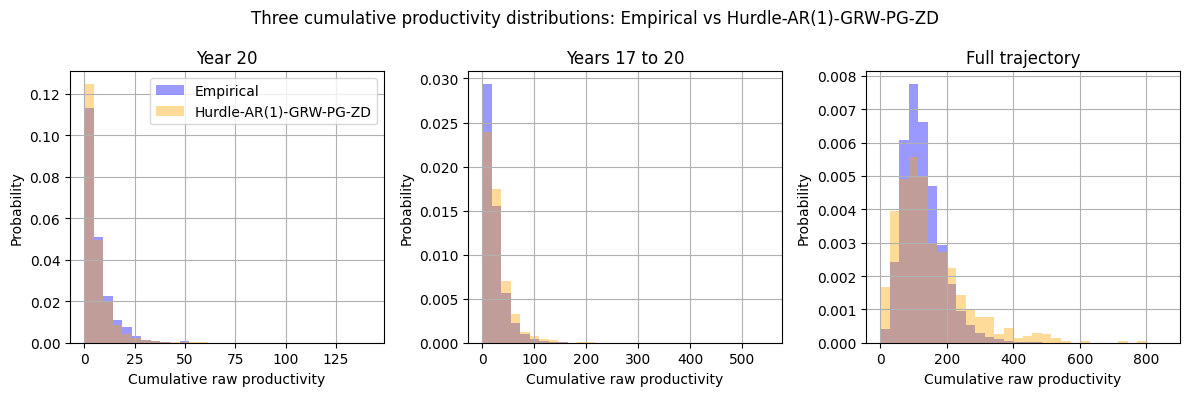

In [164]:
lastyear_sim = trajs_combined[20]
lastyear_emp = emp_panel_full[20]
hist_bins_lastyear = np.histogram_bin_edges(((np.concat([[0],lastyear_sim, lastyear_emp]))),bins=30)

lastfour_sim = trajs_combined[-4:,:].sum(axis = 0)
lastfour_emp = emp_panel_full.iloc[:, -4:].sum(axis=1).to_numpy()
hist_bins_lastfour = np.histogram_bin_edges(((np.concat([[0],lastfour_sim, lastfour_emp]))),bins=30)

cumsim = trajs_combined.sum(axis = 0)
cumemp = emp_panel_full.sum(axis=1).to_numpy()
hist_bins_cum = np.histogram_bin_edges(((np.concat([[0],cumsim, cumemp]))),bins=30)


fig, ax = plt.subplots(1,3, figsize = (12,4))

ax[0].hist((lastyear_emp), bins = hist_bins_lastyear, alpha = 0.4, color = 'blue', label = 'Empirical', density = True)
ax[0].hist((lastyear_sim),bins=hist_bins_lastyear, alpha = 0.4, color = 'orange', label= f'{MODEL_NAME}', density=True)
ax[0].set_xlabel('Cumulative raw productivity')
ax[0].set_ylabel('Probability')
ax[0].set_title('Year 20')
ax[0].legend()
ax[0].grid(True)

ax[1].hist((lastfour_sim), bins = hist_bins_lastfour, alpha = 0.4, color = 'blue', label= f'{MODEL_NAME}', density = True)
ax[1].hist((lastfour_emp),bins=hist_bins_lastfour, alpha = 0.4, color = 'orange', label= 'Empirical', density=True)
ax[1].set_xlabel('Cumulative raw productivity')
ax[1].set_ylabel('Probability')
ax[1].set_title('Years 17 to 20')
ax[1].grid(True)

ax[2].hist((cumsim), bins = hist_bins_cum, alpha = 0.4, color = 'blue', label = f'{MODEL_NAME}', density = True)
ax[2].hist((cumemp), bins=hist_bins_cum, alpha = 0.4, color = 'orange', label='Empirical', density=True)
ax[2].set_xlabel('Cumulative raw productivity')
ax[2].set_ylabel('Probability')
ax[2].set_title('Full trajectory')
ax[2].grid(True)

plt.suptitle(f'Three cumulative productivity distributions: Empirical vs {MODEL_NAME}')
plt.tight_layout()
plt.show()

fig.savefig(FIGURES / f"{MODEL_TAG}_threecumdists.png",dpi=300, bbox_inches="tight")